# Color season classification — Embeddings vs. Color features

Task: classify a face into a **12-season color type** (4 seasons ×
3 subtypes each). Two data domains:
* **old** — base dataset,
* **new** — 600 photos collected independently from Internet

2 approaches:
1. Pretrained **deep embeddings** (CLIP, then FaRL).
2. Manually selected **color features** (raw and white-balanced with von Kries by sclera).

All trained models are saved to Google Drive.


## Setup and init

In [22]:
!pip -q install scikit-learn opencv-python-headless mediapipe open_clip_torch joblib

In [23]:
from google.colab import drive
drive.mount('/content/drive')

import sys
# Folder that holds season_dataset.py AND season_features.py (shared extractor).
sys.path.insert(0, "/content/drive/MyDrive/seasons")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
from pathlib import Path
import hashlib
import numpy as np

SEED = 42

# ---- data roots ----
ROOT_OLD      = Path("/content/drive/MyDrive/seasons/train")
ROOT_OLD_TEST = Path("/content/drive/MyDrive/seasons/test")

# NEW (own) dataset: a single zip with hierarchy all/{season}/{subtype}/*.
# We unzip it and PHYSICALLY split into dataset/train and dataset/test on Drive.
NEW_ZIP       = Path("/content/drive/MyDrive/own_dataset_seasons/all.zip")
NEW_DATASET   = Path("/content/drive/MyDrive/own_dataset_seasons/dataset")
NEW_ALL       = NEW_DATASET / "all"          # unzip target: dataset/all/{season}/{subtype}
ROOT_NEW      = NEW_DATASET / "train"        # created by the physical split
ROOT_NEW_TEST = NEW_DATASET / "test"

# ---- cache + model output roots (all on Google Drive) ----
CACHE_ROOT = Path("/content/drive/MyDrive/seasons")
FEAT_CACHE = CACHE_ROOT / "feat_cache";  FEAT_CACHE.mkdir(parents=True, exist_ok=True)
CLIP_CACHE = CACHE_ROOT / "clip_emb";    CLIP_CACHE.mkdir(parents=True, exist_ok=True)
FARL_CACHE = CACHE_ROOT / "farl_emb";    FARL_CACHE.mkdir(parents=True, exist_ok=True)
MODEL_DIR  = CACHE_ROOT / "models";      MODEL_DIR.mkdir(parents=True, exist_ok=True)

def _fkey(path, variant):
    return hashlib.md5(f"{path}|{variant}".encode()).hexdigest()[:16]

def _ekey(path):
    return hashlib.md5(str(path).encode()).hexdigest()[:16]

In [25]:
SEASONS = ["spring", "summer", "autumn", "winter"]
SUBTYPES = {
    "spring": ["bright", "warm", "light"],
    "summer": ["light", "cool", "soft"],
    "autumn": ["soft", "warm", "deep"],
    "winter": ["deep", "cool", "bright"],
}
SUBTYPE_NAMES  = [f"{s}/{t}" for s in SEASONS for t in SUBTYPES[s]]
SUBTYPE_TO_IDX = {n: i for i, n in enumerate(SUBTYPE_NAMES)}
# subtype index -> season index
SUB2SEA = {SUBTYPE_TO_IDX[f"{s}/{t}"]: i
           for i, s in enumerate(SEASONS) for t in SUBTYPES[s]}
# season index -> list of its subtype indices
SEASON_SUBS = {i: [SUBTYPE_TO_IDX[f"{s}/{t}"] for t in SUBTYPES[s]]
               for i, s in enumerate(SEASONS)}

# fixed subtype order used for confusion matrices ("color ring")
RING_NAMES = [
    "spring/bright", "spring/warm", "spring/light",
    "summer/light",  "summer/cool", "summer/soft",
    "autumn/soft",   "autumn/warm", "autumn/deep",
    "winter/deep",   "winter/cool", "winter/bright",
]
RING = [SUBTYPE_TO_IDX[n] for n in RING_NAMES]

## Dataset split
Old dataset spli was left as-is. A new (own) dataset was split 80/20
All metrics are verified on **old / new / combined** dataset

In [26]:
from sklearn.model_selection import train_test_split

def gather(root):
    P, Y = [], []
    if root is None:
        return P, np.array(Y, np.int64)
    for s in SEASONS:
        for t in SUBTYPES[s]:
            d = Path(root) / s / t
            if d.is_dir():
                for p in d.rglob("*"):
                    if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".webp"):
                        P.append(str(p))
                        Y.append(SUBTYPE_TO_IDX[f"{s}/{t}"])
    return P, np.array(Y, np.int64)

def split_tvt(P, Y, seed):
    idx = np.arange(len(P))
    tr, te = train_test_split(idx, test_size=0.2, stratify=Y, random_state=seed)
    take = lambda ii: ([P[i] for i in ii], Y[ii])
    return take(tr), take(te)

# OLD: use its own test root if present, else carve 20%
oP, oY = gather(ROOT_OLD)
if ROOT_OLD_TEST is not None:
    otrP, otrY = oP, oY
    oteP, oteY = gather(ROOT_OLD_TEST)
else:
    (otrP, otrY), (oteP, oteY) = split_tvt(oP, oY, SEED)

# NEW: unzip, then PHYSICALLY split all/{season}/{subtype} into train/ and test/.
import zipfile, shutil

SPLIT_DONE = NEW_DATASET / ".split_done"   # marker so we split only once

def _find_all_root(base):
    if (base / "all").is_dir():
        return base / "all"
    hits = [h for h in base.rglob("all") if h.is_dir()]
    return hits[0] if hits else base

if SPLIT_DONE.exists():
    print("split already done — using existing train/ and test/")
else:
    if not NEW_ALL.exists():
        NEW_DATASET.mkdir(parents=True, exist_ok=True)
        with zipfile.ZipFile(NEW_ZIP) as z:
            z.extractall(NEW_DATASET)
        print("unzipped ->", NEW_DATASET)
    all_root = _find_all_root(NEW_DATASET)
    print("all root:", all_root)

    allP, allY = [], []
    for s in SEASONS:
        for t in SUBTYPES[s]:
            d = all_root / s / t
            if d.is_dir():
                for p in d.rglob("*"):
                    if p.suffix.lower() in (".png", ".jpg", ".jpeg", ".webp"):
                        allP.append(p); allY.append(f"{s}/{t}")
    print(f"gathered {len(allP)} images from all/")
    assert allP, "no images found under all/ — check the archive structure"

    allP = np.array(allP); allY = np.array(allY)
    rng = np.random.RandomState(SEED)
    copied = {"train": 0, "test": 0}
    for s in SEASONS:
        for t in SUBTYPES[s]:
            idx = np.where(allY == f"{s}/{t}")[0]
            rng.shuffle(idx)
            n_te = max(1, int(round(len(idx) * 0.2)))
            for split, part in [("test", idx[:n_te]), ("train", idx[n_te:])]:
                dst_dir = NEW_DATASET / split / s / t
                dst_dir.mkdir(parents=True, exist_ok=True)
                for i in part:
                    shutil.copy2(allP[i], dst_dir / allP[i].name)
                    copied[split] += 1
    print("copied:", copied)
    SPLIT_DONE.write_text("done")
    print("physical split complete ->", NEW_DATASET / "train", "and", NEW_DATASET / "test")

# gather from the physical train/test dirs
ntrP, ntrY = gather(ROOT_NEW)
nteP, nteY = gather(ROOT_NEW_TEST)
print(f"NEW: train {len(ntrP)} | test {len(nteP)}")

import pandas as pd
rep = pd.DataFrame({
    "subtype": [SUBTYPE_NAMES[c] for c in range(12)],
    "train": [int((ntrY == c).sum()) for c in range(12)],
    "test":  [int((nteY == c).sum()) for c in range(12)],
})
rep["total"] = rep["train"] + rep["test"]
rep["test_%"] = (100 * rep["test"] / rep["total"].clip(lower=1)).round(1)
print(rep.to_string(index=False))

trP = otrP + ntrP
trY = np.concatenate([otrY, ntrY])
teP = oteP + nteP
teY = np.concatenate([oteY, nteY])
test_src = np.array(["new" if "own_dataset" in p else "old" for p in teP])

print(f"\ntrain={len(trP)}  test={len(teP)}  "
      f"| test old/new: {int((test_src=='old').sum())}/{int((test_src=='new').sum())}")

split already done — using existing train/ and test/
NEW: train 480 | test 120
      subtype  train  test  total  test_%
spring/bright     40    10     50    20.0
  spring/warm     40    10     50    20.0
 spring/light     40    10     50    20.0
 summer/light     40    10     50    20.0
  summer/cool     40    10     50    20.0
  summer/soft     40    10     50    20.0
  autumn/soft     40    10     50    20.0
  autumn/warm     40    10     50    20.0
  autumn/deep     40    10     50    20.0
  winter/deep     40    10     50    20.0
  winter/cool     40    10     50    20.0
winter/bright     40    10     50    20.0

train=4488  test=1032  | test old/new: 912/120


## Test dataset across all methods

Color features need a detected face (MediaPipe); when detection fails, this photo is dropped. Embeddings do not have such a requirement. However as a comparison is needed for all of them, the test dataset should be the same.


In [27]:
import shutil
from pathlib import Path

LOCAL = Path("/content/local_data")

def _sync(src, dst):
    dst = Path(dst)
    if dst.exists():
        print("already local:", dst); return
    print("copying", src, "-> local ...")
    shutil.copytree(src, dst)
    print("done:", dst)

_sync("/content/drive/MyDrive/seasons", LOCAL / "seasons")
_sync("/content/drive/MyDrive/own_dataset_seasons/dataset", LOCAL / "own_dataset")

def _localize(p):
    p = str(p)
    p = p.replace("/content/drive/MyDrive/seasons", str(LOCAL / "seasons"))
    p = p.replace("/content/drive/MyDrive/own_dataset_seasons/dataset",
                  str(LOCAL / "own_dataset"))
    return p

# rebuild path lists to point at local copies
trP = [_localize(p) for p in trP]
teP = [_localize(p) for p in teP]
print(f"localized: train {len(trP)} | test {len(teP)}")

already local: /content/local_data/seasons
already local: /content/local_data/own_dataset
localized: train 4488 | test 1032


In [28]:
from season_features import extract_features, ALL_ZONES, feature_names, FEATURE_DIM
from PIL import Image
from tqdm import tqdm

ZONE_HASH = hashlib.md5("|".join(ALL_ZONES).encode()).hexdigest()[:6]
FEAT_NAMES = feature_names()

def build_color_features(paths, variant):
    """variant: 'raw' or 'vk'. Returns (X, valid_mask)."""
    use_vk = (variant == "vk")
    X, valid = [], []
    for p in tqdm(paths, desc=variant):
        fc = FEAT_CACHE / f"{_fkey(p, variant)}_{ZONE_HASH}.npy"
        if fc.exists():
            X.append(np.load(fc)); valid.append(True); continue
        img = np.array(Image.open(p).convert("RGB"), np.uint8)
        f = extract_features(img, use_von_kries=use_vk)
        if f is None:
            valid.append(False); continue
        np.save(fc, f); X.append(f); valid.append(True)
    return np.array(X), np.array(valid)

# reference mask from raw (also caches raw features for Part 6a)
Xtr_raw, vtr = build_color_features(trP, "raw")
Xte_raw, vte = build_color_features(teP, "raw")
print(f"faces detected: train {int(vtr.sum())}/{len(vtr)} | "
      f"test {int(vte.sum())}/{len(vte)}")

raw: 100%|██████████| 1032/1032 [00:00<00:00, 1576.21it/s]

faces detected: train 4481/4488 | test 1030/1032


In [29]:
# --- report what was dropped and of which type ---
def _dropped_breakdown(paths, Y, valid, split_name):
    drop = ~valid
    n = int(drop.sum())
    print(f"\n[{split_name}] dropped {n}/{len(valid)} "
          f"({100*n/max(len(valid),1):.1f}%) — no face detected")
    if n == 0:
        return
    src = np.array(["new" if "own_dataset" in p else "old" for p in paths])
    # by domain
    print("  by domain:", {d: int(((src == d) & drop).sum()) for d in ("old", "new")})
    # by subtype
    from collections import Counter
    cnt = Counter(SUBTYPE_NAMES[int(Y[i])] for i in np.where(drop)[0])
    print("  by subtype:")
    for name in SUBTYPE_NAMES:
        if cnt[name]:
            total = int((Y == SUBTYPE_TO_IDX[name]).sum())
            print(f"    {name:14} {cnt[name]:3}  (of {total} in split)")

_dropped_breakdown(trP, trY, vtr, "train")
_dropped_breakdown(teP, teY, vte, "test")


[train] dropped 7/4488 (0.2%) — no face detected
  by domain: {'old': 6, 'new': 1}
  by subtype:
    spring/bright    1  (of 331 in split)
    spring/warm      1  (of 396 in split)
    spring/light     2  (of 371 in split)
    summer/cool      1  (of 316 in split)
    autumn/warm      1  (of 323 in split)
    winter/deep      1  (of 465 in split)

[test] dropped 2/1032 (0.2%) — no face detected
  by domain: {'old': 2, 'new': 0}
  by subtype:
    summer/soft      1  (of 73 in split)
    winter/cool      1  (of 99 in split)


In [30]:

# --- apply the shared mask everywhere ---
trP_m = [p for p, v in zip(trP, vtr) if v]
teP_m = [p for p, v in zip(teP, vte) if v]
ytr = trY[vtr]
yte = teY[vte]
src_te = test_src[vte]
Xtr_raw = Xtr_raw          # already masked (only valid rows were appended)
Xte_raw = Xte_raw
print(f"aligned: train {len(trP_m)} | test {len(teP_m)} "
      f"| test old/new: {int((src_te=='old').sum())}/{int((src_te=='new').sum())}")

aligned: train 4481 | test 1030 | test old/new: 910/120


## Shared pipeline: classifier, hierarchy, evaluation

In [31]:
from sklearn.ensemble import HistGradientBoostingClassifier, BaggingClassifier

def make_clf():
    """Bagged histogram gradient boosting. Conservative settings to limit
    overfitting on a small dataset."""
    return BaggingClassifier(
        HistGradientBoostingClassifier(
            max_iter=300, learning_rate=0.08, max_depth=4,
            l2_regularization=2.0, early_stopping=True, random_state=0),
        n_estimators=8, random_state=0, n_jobs=-1)

In [32]:
def train_hierarchical(Xtr, ytr):
    """Train a season (4-class) model and a subtype (12-class) model."""
    ytr_sea = np.array([SUB2SEA[int(c)] for c in ytr])
    clf_sea = make_clf(); clf_sea.fit(Xtr, ytr_sea)
    clf_sub = make_clf(); clf_sub.fit(Xtr, ytr)
    return clf_sea, clf_sub

def predict_hierarchical(clf_sea, clf_sub, X):
    """Predict season first, then pick the best subtype WITHIN that season.
    Returns (season_pred, subtype_pred, subtype_proba)."""
    proba = clf_sub.predict_proba(X)
    sea_pred = clf_sea.predict(X)
    sub_pred = np.array([
        SEASON_SUBS[sea_pred[i]][
            int(np.argmax(proba[i, SEASON_SUBS[sea_pred[i]]]))]
        for i in range(len(X))
    ])
    return sea_pred, sub_pred, proba

def predict_flat(clf_sea, clf_sub, X):
    """Flat decoding (paper-style inference): the SAME 12-class classifier, but
    the subtype is the plain argmax over all 12 — no season restriction. The
    season head is still reported independently (its own argmax over 4), exactly
    like the paper's two separate flat tasks. Isolates the effect of the
    hierarchical trick, since the trained classifiers are identical to the
    hierarchical case — only the decoding rule differs."""
    proba = clf_sub.predict_proba(X)
    sea_pred = clf_sea.predict(X)
    # map argmax-of-12 back to a subtype index via the classifier's class order
    sub_pred = clf_sub.classes_[np.argmax(proba, axis=1)]
    return sea_pred, sub_pred, proba

In [33]:
from sklearn.metrics import (f1_score, precision_score, recall_score,
                             accuracy_score, top_k_accuracy_score)
import pandas as pd

# cyclic ±1 tolerance on the color ring
_ring_pos = {code: i for i, code in enumerate(RING)}
_ring_N = len(RING)

def _adjacent_hit(y_true, y_pred, tol=1):
    d = abs(_ring_pos[int(y_true)] - _ring_pos[int(y_pred)])
    d = min(d, _ring_N - d)          # wrap-around: winter/bright <-> spring/bright
    return d <= tol

def _topk(y_true, proba, classes, k):
    """Top-k accuracy robust to missing classes in `classes`."""
    try:
        return float(top_k_accuracy_score(y_true, proba, k=k, labels=classes))
    except Exception:
        return float("nan")

def evaluate(clf_sea, clf_sub, X, y, src, method_name, mode="hier"):
    """Paper-format metrics for BOTH tasks, per old / new / combined slice.
    mode='hier' uses hierarchical decoding (season restricts subtype);
    mode='flat' uses plain argmax over 12 (paper-style, same classifier).
    Season task: Accuracy / Precision / Recall / F1 / Top-2 (4 classes).
    Subtype task: Accuracy / Precision / Recall / F1 / Top-3 (12 classes) + ±1.
    Returns a tidy DataFrame (one row per slice)."""
    decode = predict_hierarchical if mode == "hier" else predict_flat
    sea_pred, sub_pred, sub_proba = decode(clf_sea, clf_sub, X)
    sea_proba = clf_sea.predict_proba(X)
    y_sea = np.array([SUB2SEA[int(c)] for c in y])
    tagged = f"{method_name} [{mode}]"

    rows = []
    slices = [("old", src == "old"), ("new", src == "new"),
              ("combined", np.ones(len(y), bool))]
    for tag, m in slices:
        if m.sum() == 0:
            continue
        adj = np.array([_adjacent_hit(t, p) for t, p in zip(y[m], sub_pred[m])])
        rows.append({
            "method": tagged, "mode": mode, "slice": tag, "n": int(m.sum()),
            # --- season (4-class) ---
            "S_acc":  accuracy_score(y_sea[m], sea_pred[m]),
            "S_prec": precision_score(y_sea[m], sea_pred[m], average="macro",
                                      labels=list(range(4)), zero_division=0),
            "S_rec":  recall_score(y_sea[m], sea_pred[m], average="macro",
                                   labels=list(range(4)), zero_division=0),
            "S_f1":   f1_score(y_sea[m], sea_pred[m], average="macro",
                               labels=list(range(4)), zero_division=0),
            "S_top2": _topk(y_sea[m], sea_proba[m], clf_sea.classes_, 2),
            # --- subtype (12-class) ---
            "T_acc":  accuracy_score(y[m], sub_pred[m]),
            "T_prec": precision_score(y[m], sub_pred[m], average="macro",
                                      labels=list(range(12)), zero_division=0),
            "T_rec":  recall_score(y[m], sub_pred[m], average="macro",
                                   labels=list(range(12)), zero_division=0),
            "T_f1":   f1_score(y[m], sub_pred[m], average="macro",
                               labels=list(range(12)), zero_division=0),
            "T_top3": _topk(y[m], sub_proba[m], clf_sub.classes_, 3),
            "T_pm1":  float(adj.mean()),
        })
    df = pd.DataFrame(rows)
    print(f"=== {tagged} ===")
    season_cols = ["n", "S_acc", "S_prec", "S_rec", "S_f1", "S_top2"]
    sub_cols    = ["T_acc", "T_prec", "T_rec", "T_f1", "T_top3", "T_pm1"]
    print("[season 4-class]")
    print(df.set_index("slice")[season_cols].round(3).to_string())
    print("[subtype 12-class]")
    print(df.set_index("slice")[sub_cols].round(3).to_string())
    return df, (sea_pred, sub_pred, sub_proba)

def eval_both(clf_sea, clf_sub, X, y, src, method_name):
    """Score a method BOTH ways: hierarchical (ours) and flat (paper-style).
    Returns the concatenated DataFrame; the hierarchical predictions are
    returned too (for confusion matrices)."""
    df_h, preds_h = evaluate(clf_sea, clf_sub, X, y, src, method_name, mode="hier")
    df_f, _       = evaluate(clf_sea, clf_sub, X, y, src, method_name, mode="flat")
    return pd.concat([df_h, df_f], ignore_index=True), preds_h

In [60]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def plot_subtype_cm(y, sub_pred, src, title, which="new"):
    """Row-normalized 12x12 subtype confusion matrix for one slice."""
    m = (src == which) if which in ("old", "new") else np.ones(len(y), bool)
    if m.sum() == 0:
        print("no samples for", which); return
    cm = confusion_matrix(y[m], sub_pred[m], labels=RING)
    cmn = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
    fig, ax = plt.subplots(figsize=(9, 8))
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    ax.set_xticks(range(12)); ax.set_xticklabels(RING_NAMES, rotation=90, fontsize=8)
    ax.set_yticks(range(12)); ax.set_yticklabels(RING_NAMES, fontsize=8)
    for i in range(12):
        for j in range(12):
            ax.text(j, i, f"{cmn[i, j]:.2f}", ha="center", va="center",
                    fontsize=6, color="white" if cmn[i, j] > 0.5 else "black")
    ax.set_title(f"{title} — subtype ({which})")
    ax.set_xlabel("pred"); ax.set_ylabel("true")
    plt.colorbar(im, fraction=0.046); plt.tight_layout(); plt.show()


def cm_for(sub_pred, title):
    plot_subtype_cm(yte, sub_pred, src_te, title, which="old")
    plot_subtype_cm(yte, sub_pred, src_te, title, which="new")
    plot_subtype_cm(yte, sub_pred, src_te, title, which="combined")

In [35]:
import joblib

def save_model(clf_sea, clf_sub, method_name, extra=None):
    """Persist a trained pair to Google Drive."""
    bundle = {
        "clf_sea": clf_sea, "clf_sub": clf_sub, "method": method_name,
        "SEASONS": SEASONS, "SUBTYPES": SUBTYPES,
        "SUBTYPE_NAMES": SUBTYPE_NAMES, "SUBTYPE_TO_IDX": SUBTYPE_TO_IDX,
        "SUB2SEA": SUB2SEA, "SEASON_SUBS": SEASON_SUBS,
    }
    if extra:
        bundle.update(extra)
    path = MODEL_DIR / f"model_{method_name}.joblib"
    joblib.dump(bundle, path)
    print("saved ->", path)
    return path

all_results = []   # collected per-method DataFrames for the final comparison

## Embeddings - CLIP (ViT-B/32)

In [36]:
import open_clip, torch
from PIL import Image
from tqdm import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model, _, clip_preprocess = open_clip.create_model_and_transforms(
    "ViT-B-32", pretrained="laion2b_s34b_b79k")
clip_model = clip_model.to(device).eval()

def build_clip_embeddings(paths, desc="CLIP"):
    E = []
    for p in tqdm(paths, desc=desc):
        fc = CLIP_CACHE / f"{_ekey(p)}.npy"
        if fc.exists():
            E.append(np.load(fc)); continue
        img = clip_preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = clip_model.encode_image(img).squeeze().cpu().numpy().astype(np.float32)
        np.save(fc, emb); E.append(emb)
    return np.array(E)

# Use the SAME masked images as color features (shared valid mask).
Etr = build_clip_embeddings(trP_m)
Ete = build_clip_embeddings(teP_m)
print("CLIP:", Etr.shape, Ete.shape)

CLIP: 100%|██████████| 1030/1030 [00:13<00:00, 75.67it/s]

CLIP: (4481, 512) (1030, 512)


In [37]:
clip_sea, clip_sub = train_hierarchical(Etr, ytr)
df_clip, _ = eval_both(clip_sea, clip_sub, Ete, yte, src_te, "CLIP")
all_results.append(df_clip)
save_model(clip_sea, clip_sub, "CLIP", extra={"embed_dim": int(Etr.shape[1])})

=== CLIP [hier] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.531   0.528  0.521  0.517   0.825
new        120  0.625   0.630  0.625  0.620   0.817
combined  1030  0.542   0.540  0.535  0.532   0.824
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice                                               
old       0.297   0.279  0.267  0.265   0.655  0.592
new       0.392   0.385  0.392  0.379   0.717  0.675
combined  0.308   0.296  0.284  0.282   0.662  0.602
=== CLIP [flat] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.531   0.528  0.521  0.517   0.825
new        120  0.625   0.630  0.625  0.620   0.817
combined  1030  0.542   0.540  0.535  0.532   0.824
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice                                             

PosixPath('/content/drive/MyDrive/seasons/models/model_CLIP.joblib')

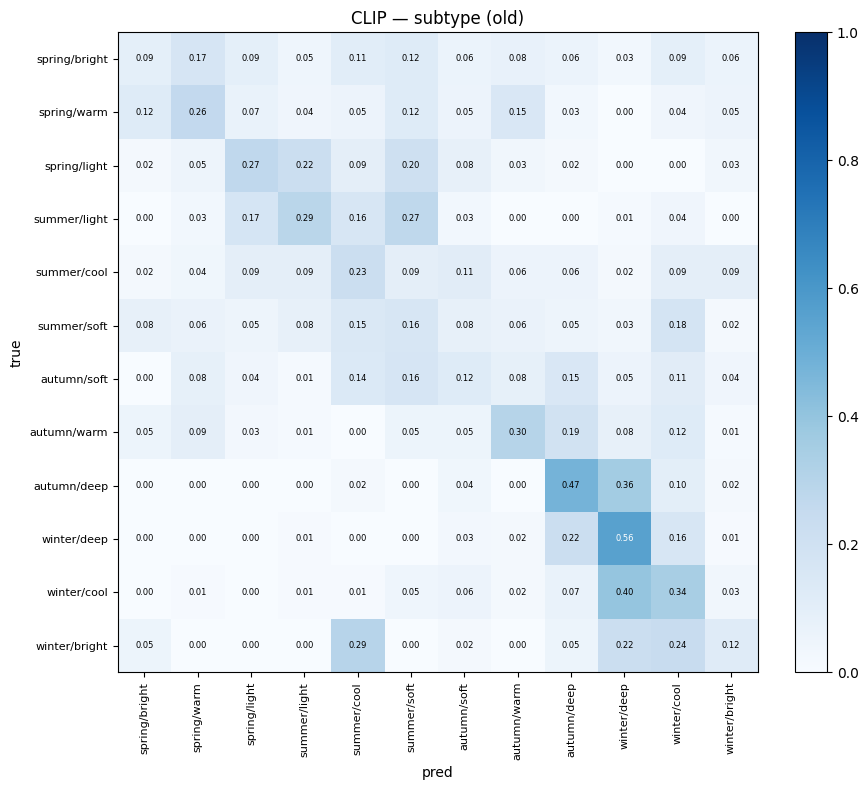

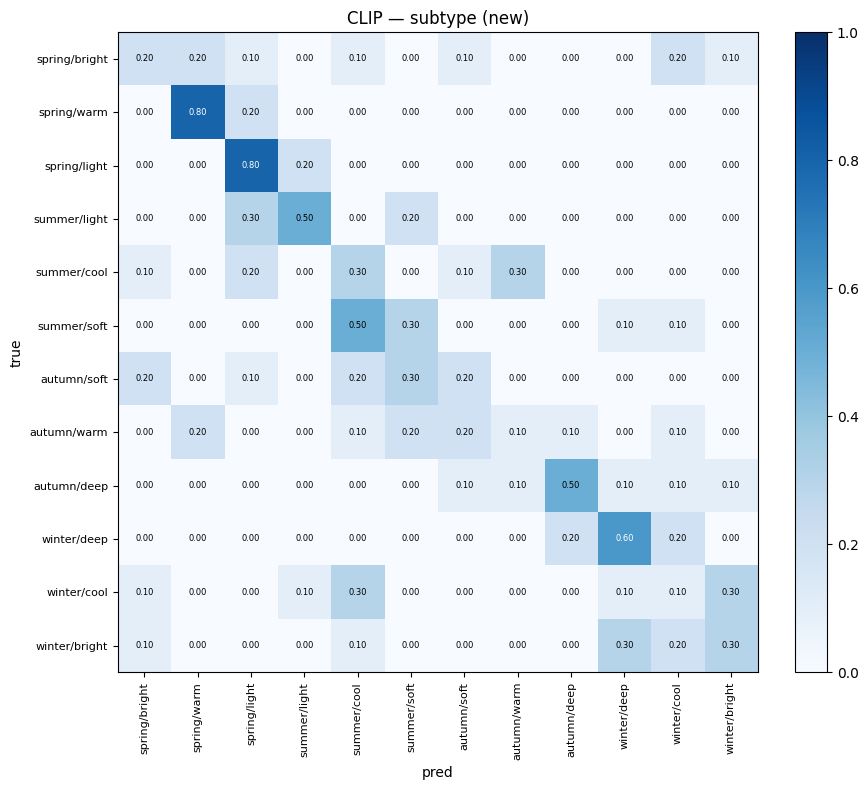

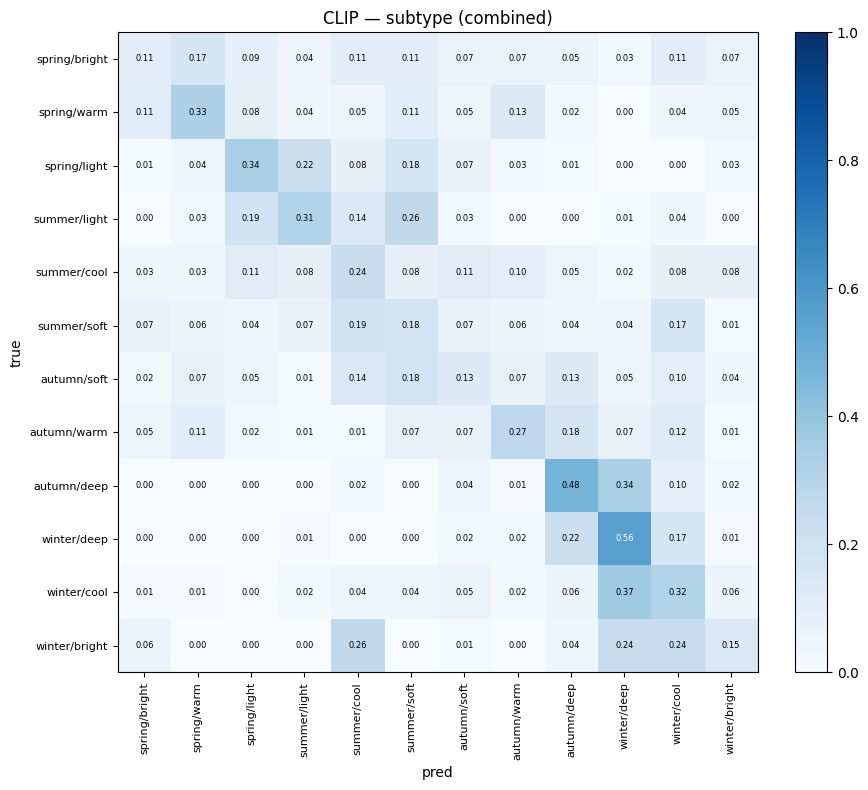

In [63]:
_, clip_sub_pred, _ = predict_hierarchical(clip_sea, clip_sub, Ete)
cm_for(clip_sub_pred, "CLIP")

## Embeddings - FaRL16 (ViT-B/16, face-pretrained)

Same pipeline, a face-specialized backbone. We use **FaRL16** (16 training
epochs), which is the paper's best backbone on the 12-subtype task, so the
comparison against the published subtype numbers (F1 0.310) is apples-to-apples.


In [38]:
!wget -q -O FaRL-Base-Patch16-LAIONFace20M-ep16.pth \\
  https://github.com/FacePerceiver/FaRL/releases/download/pretrained_weights/FaRL-Base-Patch16-LAIONFace20M-ep16.pth


In [39]:
farl_model, _, farl_preprocess = open_clip.create_model_and_transforms("ViT-B-16")
farl_state = torch.load("FaRL-Base-Patch16-LAIONFace20M-ep16.pth", map_location="cpu")
if "state_dict" in farl_state:
    farl_state = farl_state["state_dict"]
missing, unexpected = farl_model.load_state_dict(farl_state, strict=False)
print("missing:", len(missing), "| unexpected:", len(unexpected))  # a few is fine
farl_model = farl_model.to(device).eval()

def build_farl_embeddings(paths, desc="FaRL"):
    E = []
    for p in tqdm(paths, desc=desc):
        fc = FARL_CACHE / f"{_ekey(p)}.npy"
        if fc.exists():
            E.append(np.load(fc)); continue
        img = farl_preprocess(Image.open(p).convert("RGB")).unsqueeze(0).to(device)
        with torch.no_grad():
            emb = farl_model.encode_image(img).squeeze().cpu().numpy().astype(np.float32)
        np.save(fc, emb); E.append(emb)
    return np.array(E)

Ftr = build_farl_embeddings(trP_m)
Fte = build_farl_embeddings(teP_m)
print("FaRL:", Ftr.shape, Fte.shape)

missing: 0 | unexpected: 17


FaRL: 100%|██████████| 1030/1030 [00:14<00:00, 68.89it/s]

FaRL: (4481, 512) (1030, 512)


In [40]:
# Method A: FaRL frozen + boosting (our classifier on frozen embeddings)
farl_sea, farl_sub = train_hierarchical(Ftr, ytr)
df_farl, _ = eval_both(farl_sea, farl_sub, Fte, yte, src_te, "FaRL16 frozen + boosting")
all_results.append(df_farl)
save_model(farl_sea, farl_sub, "FaRL_frozen_boosting",
           extra={"embed_dim": int(Ftr.shape[1])})

=== FaRL16 frozen + boosting [hier] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.512   0.503  0.503  0.499   0.832
new        120  0.617   0.625  0.617  0.613   0.833
combined  1030  0.524   0.516  0.517  0.513   0.832
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice                                               
old       0.282   0.261  0.257  0.254   0.640  0.575
new       0.392   0.380  0.392  0.371   0.775  0.633
combined  0.295   0.277  0.273  0.270   0.655  0.582
=== FaRL16 frozen + boosting [flat] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.512   0.503  0.503  0.499   0.832
new        120  0.617   0.625  0.617  0.613   0.833
combined  1030  0.524   0.516  0.517  0.513   0.832
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice     

PosixPath('/content/drive/MyDrive/seasons/models/model_FaRL_frozen_boosting.joblib')

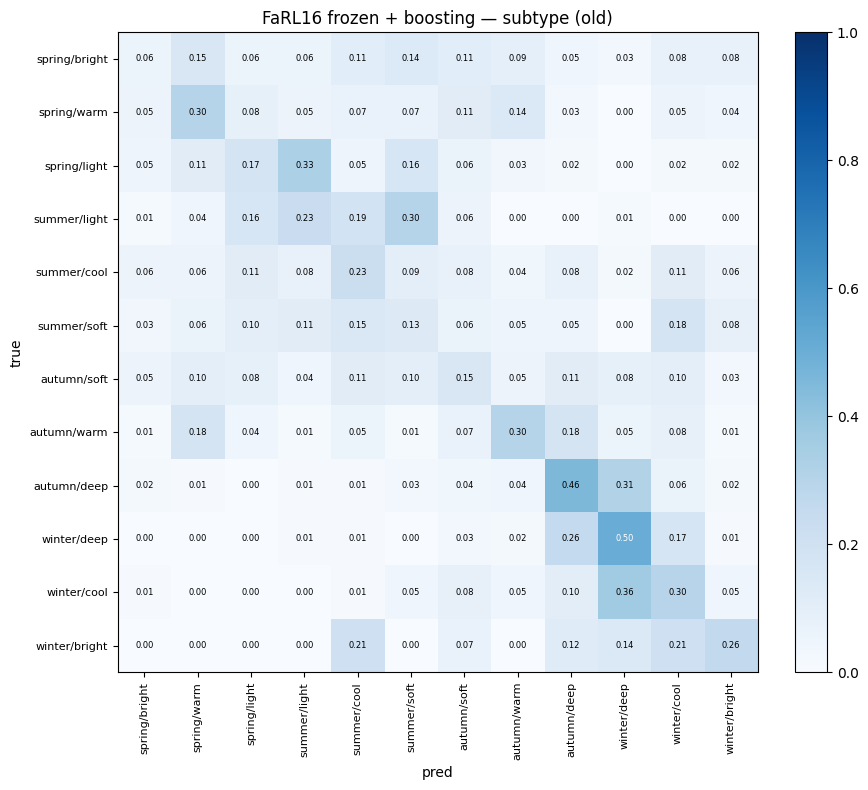

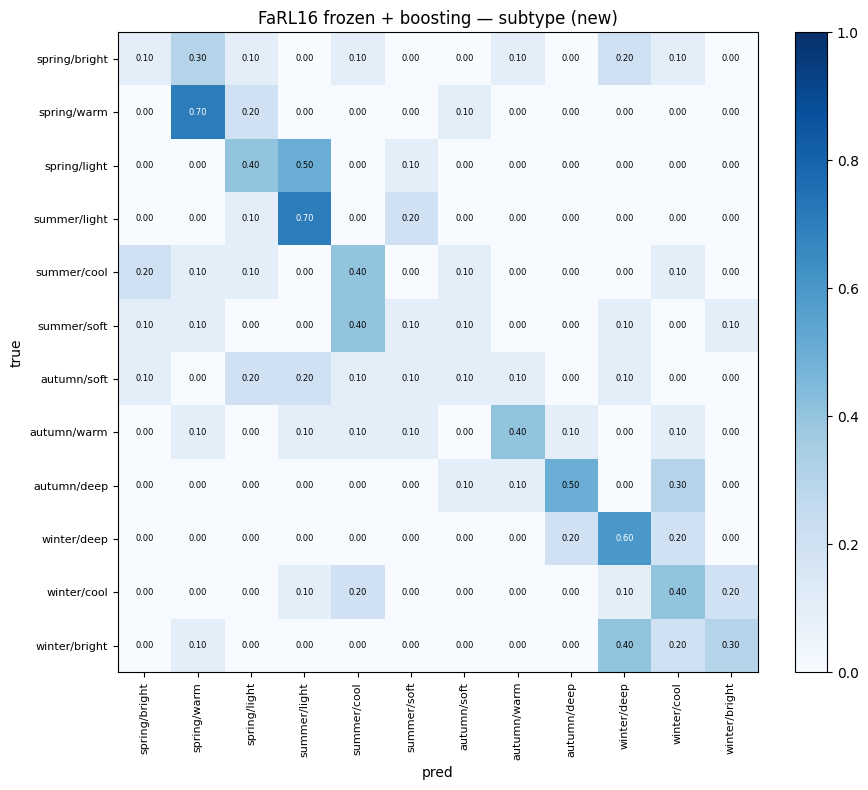

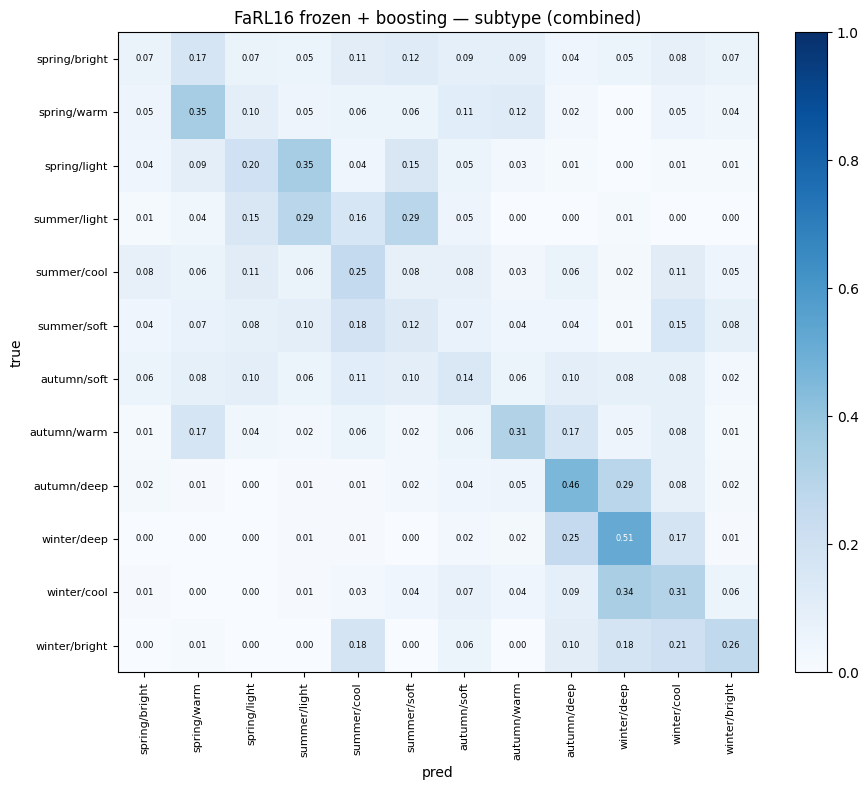

In [64]:
_, farl_sub_pred, _ = predict_hierarchical(farl_sea, farl_sub, Fte)
cm_for(farl_sub_pred, "FaRL16 frozen + boosting")

### FaRL frozen + FC head (paper)

In [68]:
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# Paper-style FC head in PyTorch on the FROZEN embeddings (fast, no aug needed).
# Two FC layers (input -> input/2 -> n_out), ReLU, dropout 0.5, AdamW,
# cosine annealing with warm restarts, 50 epochs.

class FCHead(nn.Module):
    def __init__(self, in_dim, n_out):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, in_dim // 2), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(in_dim // 2, n_out))
    def forward(self, x):
        return self.net(x)

class TorchProbaClf:
    """sklearn-like wrapper so a FCHead plugs into predict_hierarchical/eval_both."""
    def __init__(self, model, classes, device):
        self.model = model.eval(); self.classes_ = np.array(classes); self.device = device
    def predict_proba(self, X):
        self.model.eval()
        with torch.no_grad():
            xb = torch.tensor(np.asarray(X, np.float32), device=self.device)
            return torch.softmax(self.model(xb), dim=1).cpu().numpy()
    def predict(self, X):
        return self.classes_[np.argmax(self.predict_proba(X), axis=1)]

def train_fc_torch(Xtr, ytr_, n_out, epochs=50, seed=0):
    torch.manual_seed(seed)
    ds = TensorDataset(torch.tensor(Xtr, dtype=torch.float32),
                       torch.tensor(np.asarray(ytr_), dtype=torch.long))
    ld = DataLoader(ds, batch_size=64, shuffle=True)
    model = FCHead(Xtr.shape[1], n_out).to(device)
    opt = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, eta_min=1e-5)
    lossf = nn.CrossEntropyLoss()
    for ep in range(epochs):
        model.train()
        for xb, yb in ld:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); lossf(model(xb), yb).backward(); opt.step()
        sched.step()
    return TorchProbaClf(model, list(range(n_out)), device)

ytr_sea = np.array([SUB2SEA[int(c)] for c in ytr])
fc_sea = train_fc_torch(Ftr, ytr_sea, 4)
fc_sub = train_fc_torch(Ftr, ytr, 12)
df_fc, _ = eval_both(fc_sea, fc_sub, Fte, yte, src_te, "FaRL16 frozen + FC (paper)")
all_results.append(df_fc)

=== FaRL16 frozen + FC (paper) [hier] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.511   0.502  0.505  0.502   0.810
new        120  0.675   0.675  0.675  0.672   0.892
combined  1030  0.530   0.523  0.525  0.523   0.819
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice                                               
old       0.275   0.248  0.253  0.248   0.642  0.586
new       0.483   0.492  0.483  0.481   0.825  0.733
combined  0.299   0.278  0.281  0.276   0.663  0.603
=== FaRL16 frozen + FC (paper) [flat] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.511   0.502  0.505  0.502   0.810
new        120  0.675   0.675  0.675  0.672   0.892
combined  1030  0.530   0.523  0.525  0.523   0.819
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice 

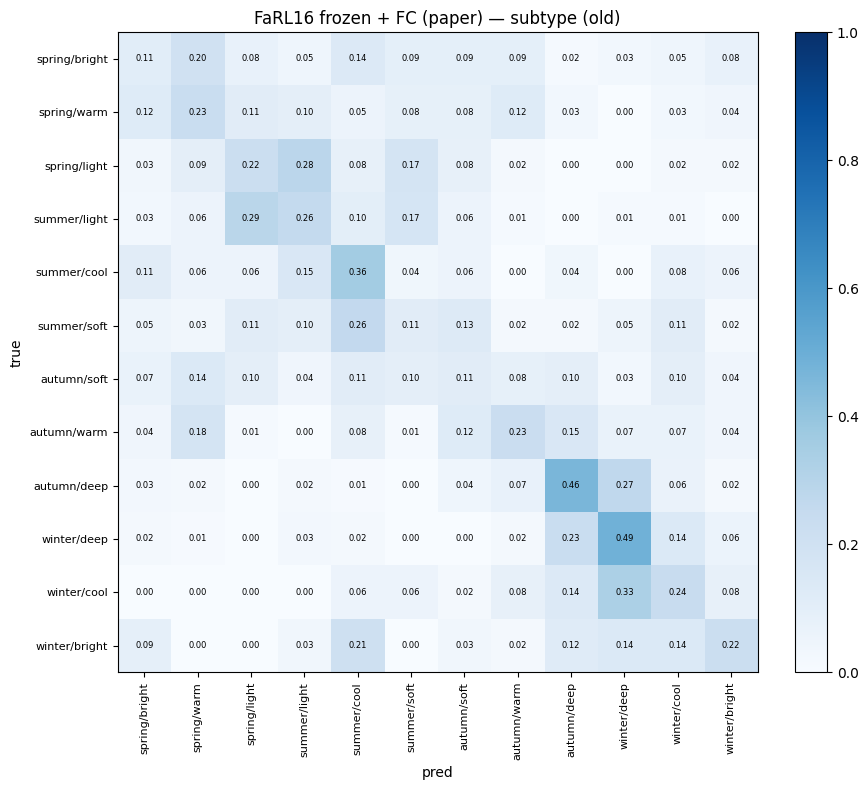

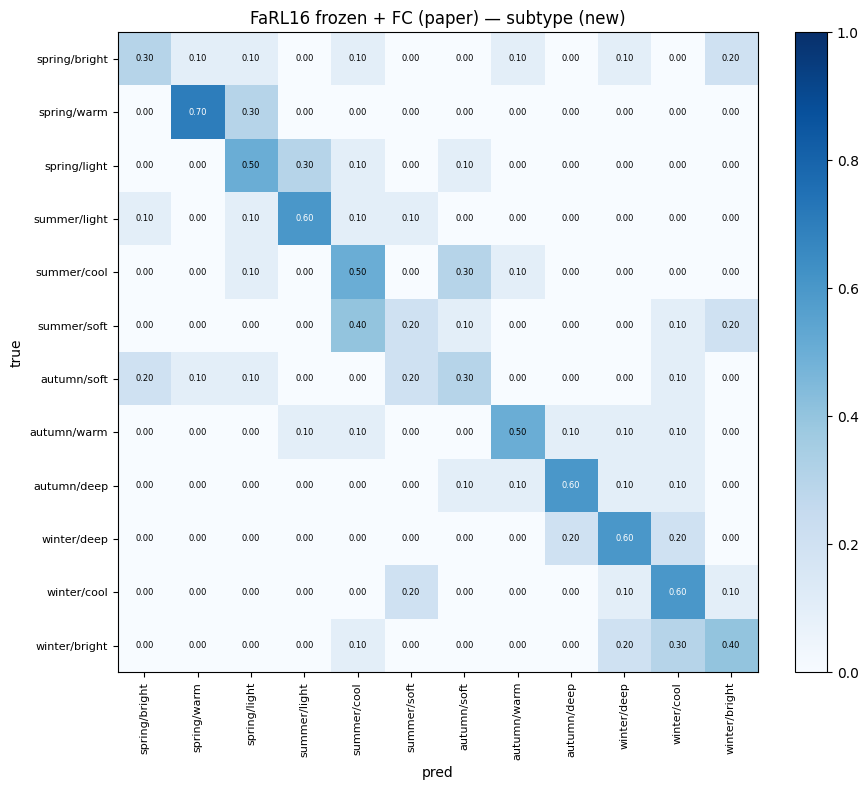

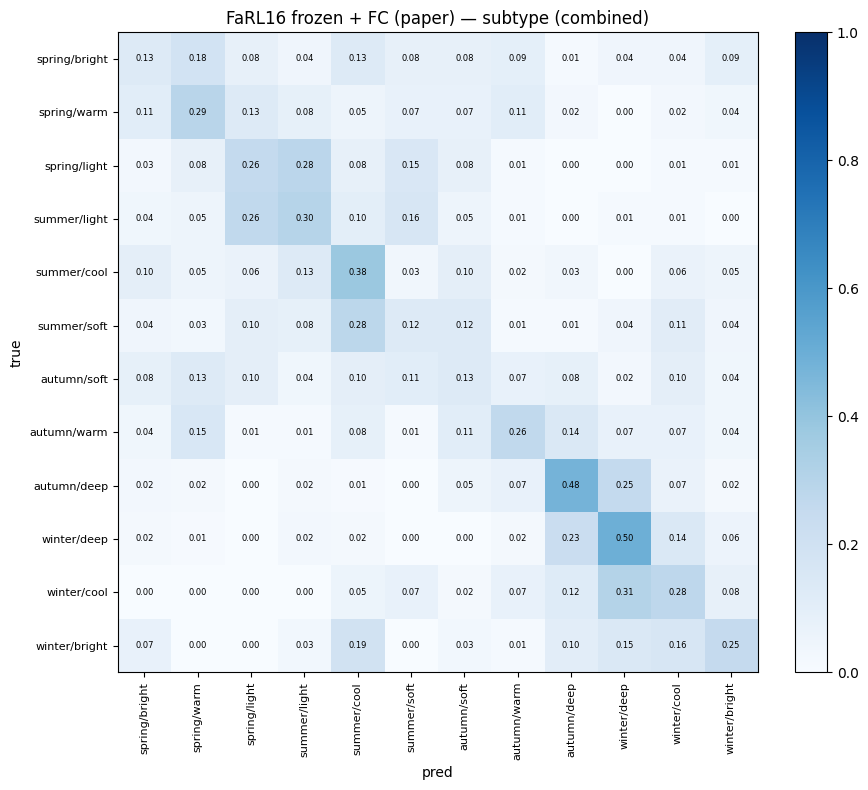

In [70]:
_, fc_sub_pred, _ = predict_hierarchical(fc_sea, fc_sub, Fte)
cm_for(fc_sub_pred, "FaRL16 frozen + FC (paper)")

### FaRL partial fine-tuning (last 2 transformer blocks)

Unfreeze the **last 2 transformer blocks** of the FaRL image encoder

In [71]:
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

RUN_FINETUNE = True   # set False to skip

# paper augmentations for fine-tuning (train only)
_AUG = T.Compose([
    T.RandomResizedCrop(224, scale=(0.8, 1.0)),
    T.RandomHorizontalFlip(0.5),
    T.ColorJitter(brightness=0.4, contrast=0.2, saturation=0.2),
    T.RandomAdjustSharpness(sharpness_factor=2, p=0.2),
])

class FaceDS(Dataset):
    def __init__(self, paths, labels, preprocess, augment=False):
        self.paths, self.labels = paths, labels
        self.pre, self.augment = preprocess, augment
    def __len__(self):
        return len(self.paths)
    def __getitem__(self, i):
        img = Image.open(self.paths[i]).convert("RGB")
        if self.augment:
            img = _AUG(img)
        return self.pre(img), int(self.labels[i])

class FaRLClassifier(nn.Module):
    def __init__(self, backbone, embed_dim, n_out, n_unfreeze=2):
        super().__init__()
        self.backbone = backbone
        for p in self.backbone.parameters():
            p.requires_grad = False
        for blk in self.backbone.visual.transformer.resblocks[-n_unfreeze:]:
            for p in blk.parameters():
                p.requires_grad = True
        self.head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2), nn.ReLU(),
            nn.Dropout(0.5), nn.Linear(embed_dim // 2, n_out))
    def forward(self, x):
        return self.head(self.backbone.encode_image(x))

In [72]:
def finetune(n_out, y_train, y_test, task_name, epochs=50, n_unfreeze=2):
    """Fine-tune FaRL (last n_unfreeze blocks) + FC head, paper-style:
    AdamW, cosine annealing w/ warm restarts, 50 epochs, augmented train."""
    bb, _, _ = open_clip.create_model_and_transforms("ViT-B-16")
    st = torch.load("FaRL-Base-Patch16-LAIONFace20M-ep16.pth", map_location="cpu")
    bb.load_state_dict(st.get("state_dict", st), strict=False)
    model = FaRLClassifier(bb, Ftr.shape[1], n_out, n_unfreeze).to(device)

    tr_ld = DataLoader(FaceDS(trP_m, y_train, farl_preprocess, augment=True),
                       batch_size=64, shuffle=True, num_workers=2)
    te_ld = DataLoader(FaceDS(teP_m, y_test, farl_preprocess, augment=False),
                       batch_size=64, shuffle=False, num_workers=2)

    head_p = list(model.head.parameters())
    bb_p = [p for p in model.backbone.parameters() if p.requires_grad]
    opt = torch.optim.AdamW([{"params": head_p, "lr": 1e-3},
                             {"params": bb_p, "lr": 1e-4}], weight_decay=1e-5)
    sched = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=10, eta_min=1e-5)
    lossf = nn.CrossEntropyLoss()

    for ep in range(epochs):
        model.train(); tot = 0.0
        for xb, yb in tqdm(tr_ld, desc=f"{task_name} ep{ep+1}/{epochs}", leave=False):
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad(); loss = lossf(model(xb), yb)
            loss.backward(); opt.step(); tot += loss.item() * len(xb)
        sched.step()
        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"  {task_name} epoch {ep+1}/{epochs}: loss {tot/len(tr_ld.dataset):.4f}")

    model.eval(); probs = []
    with torch.no_grad():
        for xb, _ in te_ld:
            probs.append(torch.softmax(model(xb.to(device)), dim=1).cpu().numpy())
    return model, np.concatenate(probs)

In [73]:
if RUN_FINETUNE:
    ytr_sea = np.array([SUB2SEA[int(c)] for c in ytr])
    yte_sea = np.array([SUB2SEA[int(c)] for c in yte])

    ft_sea_model, sea_proba_ft = finetune(4,  ytr_sea, yte_sea, "season")
    ft_sub_model, sub_proba_ft = finetune(12, ytr,     yte,     "subtype")

    # decode both ways from the SAME fine-tuned probabilities
    sea_pred_ft = sea_proba_ft.argmax(1)
    sub_pred_hier = np.array([
        SEASON_SUBS[sea_pred_ft[i]][
            int(np.argmax(sub_proba_ft[i, SEASON_SUBS[sea_pred_ft[i]]]))]
        for i in range(len(sub_proba_ft))
    ])
    sub_pred_flat = sub_proba_ft.argmax(1)

    import pandas as pd
    def _ft_rows(sub_pred, mode):
        rows = []
        for tag, m in [("old", src_te == "old"), ("new", src_te == "new"),
                       ("combined", np.ones(len(yte), bool))]:
            if m.sum() == 0:
                continue
            adj = np.array([_adjacent_hit(t, p) for t, p in zip(yte[m], sub_pred[m])])
            rows.append({
                "method": f"FaRL16 fine-tuned (2 blocks) [{mode}]", "mode": mode,
                "slice": tag, "n": int(m.sum()),
                "S_acc":  accuracy_score(yte_sea[m], sea_pred_ft[m]),
                "S_prec": precision_score(yte_sea[m], sea_pred_ft[m], average="macro",
                                          labels=list(range(4)), zero_division=0),
                "S_rec":  recall_score(yte_sea[m], sea_pred_ft[m], average="macro",
                                       labels=list(range(4)), zero_division=0),
                "S_f1":   f1_score(yte_sea[m], sea_pred_ft[m], average="macro",
                                   labels=list(range(4)), zero_division=0),
                "S_top2": _topk(yte_sea[m], sea_proba_ft[m], list(range(4)), 2),
                "T_acc":  accuracy_score(yte[m], sub_pred[m]),
                "T_prec": precision_score(yte[m], sub_pred[m], average="macro",
                                          labels=list(range(12)), zero_division=0),
                "T_rec":  recall_score(yte[m], sub_pred[m], average="macro",
                                       labels=list(range(12)), zero_division=0),
                "T_f1":   f1_score(yte[m], sub_pred[m], average="macro",
                                   labels=list(range(12)), zero_division=0),
                "T_top3": _topk(yte[m], sub_proba_ft[m], list(range(12)), 3),
                "T_pm1":  float(adj.mean()),
            })
        return rows

    df_ft = pd.DataFrame(_ft_rows(sub_pred_hier, "hier") +
                         _ft_rows(sub_pred_flat, "flat"))
    print("=== FaRL16 fine-tuned (2 blocks) — hier vs flat ===")
    print(df_ft.set_index(["method","slice"])[["n","S_acc","S_f1",
          "T_acc","T_f1","T_top3","T_pm1"]].round(3).to_string())
    all_results.append(df_ft)

    torch.save(ft_sub_model.state_dict(), MODEL_DIR / "model_FaRL_finetuned_subtype.pt")
    torch.save(ft_sea_model.state_dict(), MODEL_DIR / "model_FaRL_finetuned_season.pt")
    print("saved fine-tuned models to", MODEL_DIR)

  season epoch 1/50: loss 1.0996


  season epoch 5/50: loss 0.6255


  season epoch 10/50: loss 0.4014


  season epoch 15/50: loss 0.2300


  season epoch 20/50: loss 0.0802


...

  subtype epoch 35/50: loss 0.0624


  subtype epoch 40/50: loss 0.0432


  subtype epoch 45/50: loss 0.0451


  subtype epoch 50/50: loss 0.0310


=== FaRL16 fine-tuned (2 blocks) — hier vs flat ===
                                                 n  S_acc   S_f1  T_acc   T_f1  T_top3  T_pm1
method                              slice                                                    
FaRL16 fine-tuned (2 blocks) [hier] old        910  0.515  0.507  0.265  0.246   0.631  0.587
                                    new        120  0.767  0.769  0.567  0.556   0.783  0.775
                                    combined  1030  0.545  0.538  0.300  0.285   0.649  0.609
FaRL16 fine-tuned (2 blocks) [flat] old        910  0.515  0.507  0.277  0.257   0.631  0.578
                                    new        120  0.767  0.769  0.542  0.528   0.783  0.733
                                    combined  1030  0.545  0.538  0.308  0.292   0.649  0.596
saved fine-tuned models to /content/drive/MyDrive/seasons/models


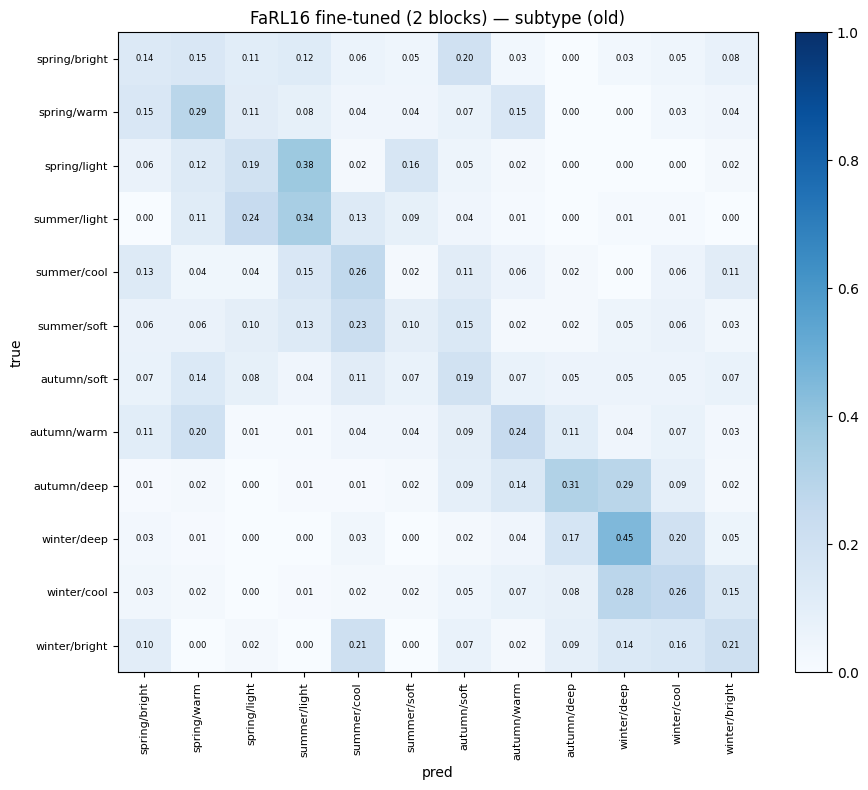

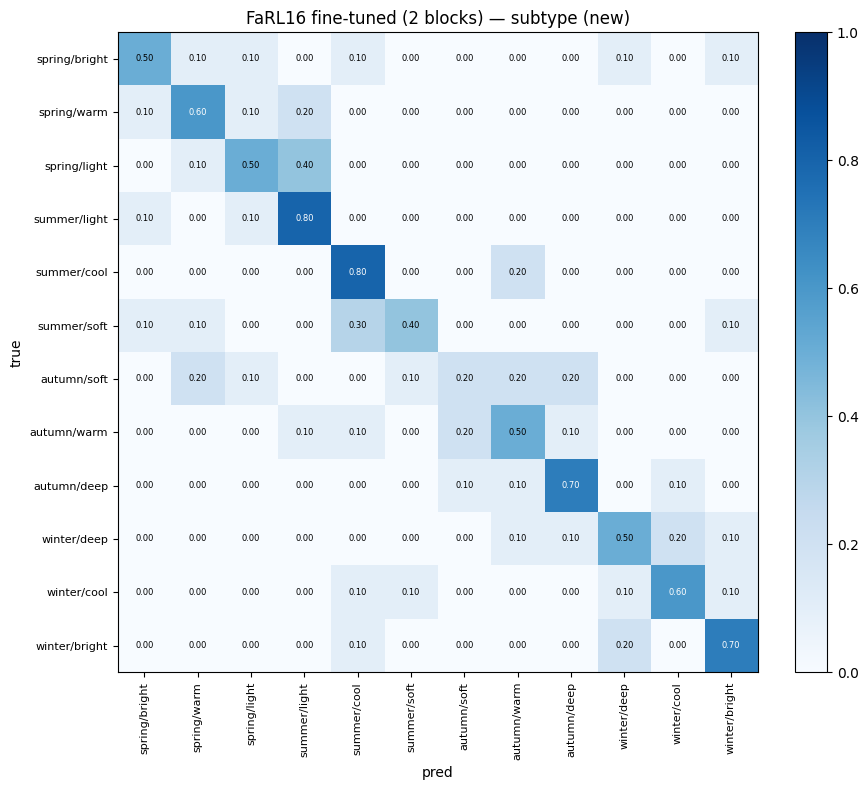

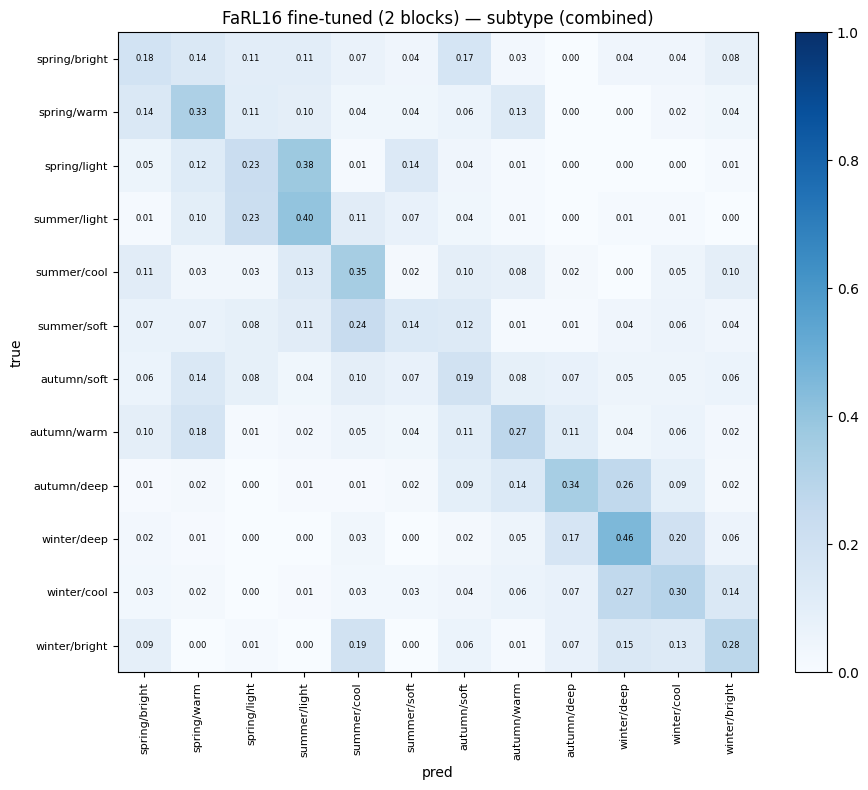

In [81]:
if RUN_FINETUNE:
    cm_for(sub_pred_hier, "FaRL16 fine-tuned (2 blocks)")

## Manual color features


In [45]:
def run_color(Xtr, Xte, variant):
    """Train + eval + save for a color-feature matrix already aligned to the
    shared mask (rows correspond to ytr / yte)."""
    print(f"[{variant}] train {Xtr.shape} test {Xte.shape}")
    clf_sea, clf_sub = train_hierarchical(Xtr, ytr)
    df, (sea_pred, sub_pred, proba) = eval_both(
        clf_sea, clf_sub, Xte, yte, src_te, f"color-{variant}")
    save_model(clf_sea, clf_sub, f"color-{variant}",
               extra={"variant": variant, "feat_dim": int(Xtr.shape[1])})
    return dict(df=df, clf_sea=clf_sea, clf_sub=clf_sub,
                Xtr=Xtr, Xte=Xte, sea_pred=sea_pred, sub_pred=sub_pred)

### Raw (no white balance)


[raw] train (4481, 330) test (1030, 330)
=== color-raw [hier] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.548   0.543  0.537  0.537   0.820
new        120  0.575   0.584  0.575  0.571   0.808
combined  1030  0.551   0.547  0.543  0.543   0.818
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice                                               
old       0.296   0.277  0.274  0.270   0.619  0.601
new       0.333   0.333  0.333  0.318   0.625  0.625
combined  0.300   0.281  0.282  0.278   0.619  0.604
=== color-raw [flat] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.548   0.543  0.537  0.537   0.820
new        120  0.575   0.584  0.575  0.571   0.808
combined  1030  0.551   0.547  0.543  0.543   0.818
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1

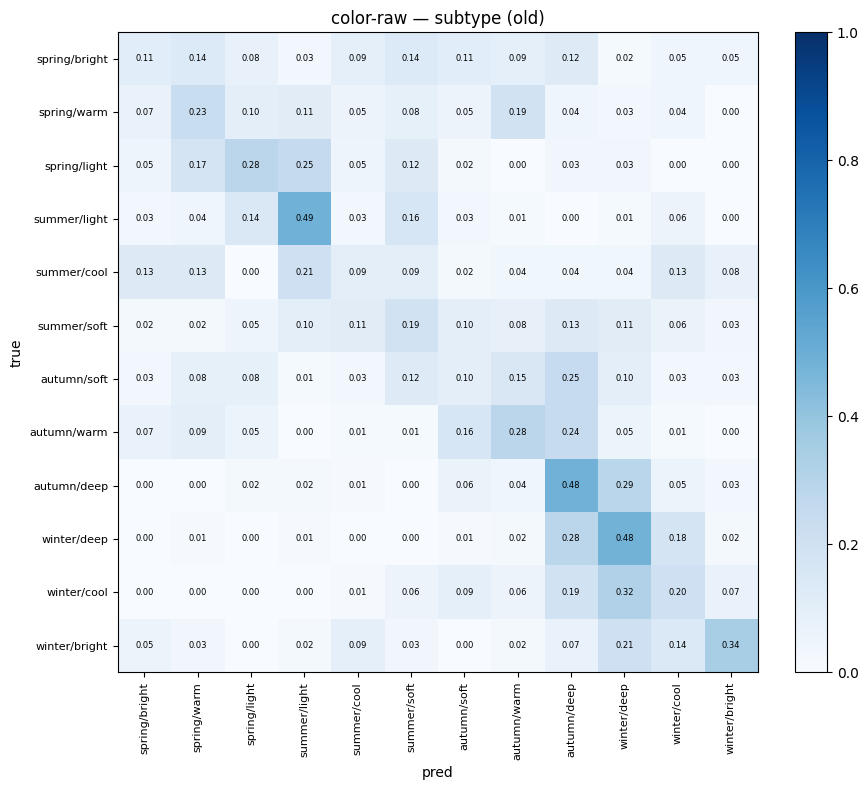

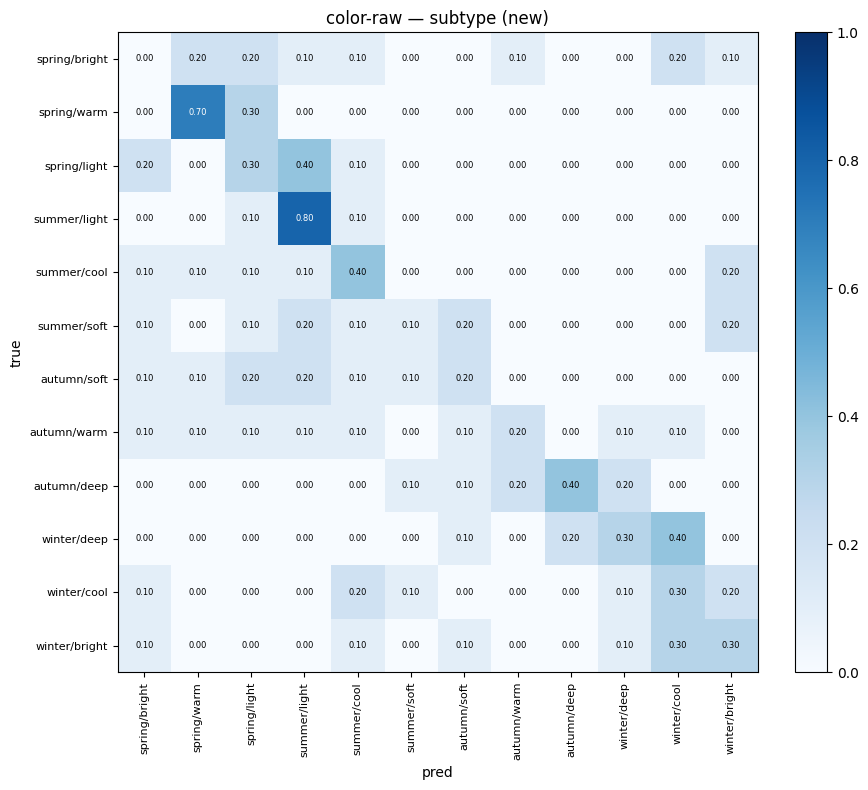

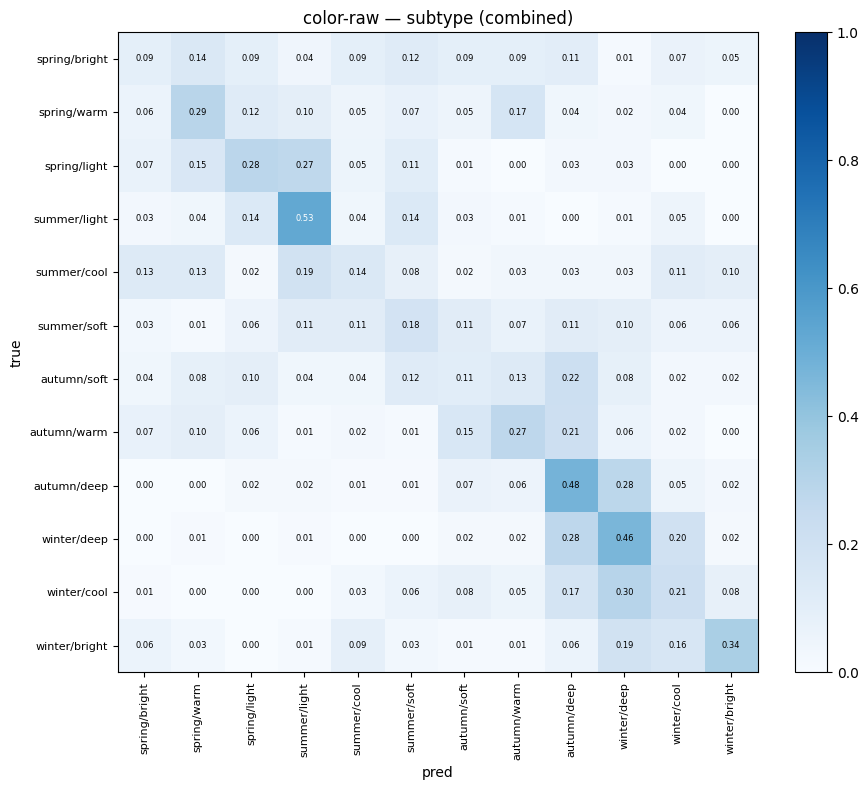

In [61]:
res_raw = run_color(Xtr_raw, Xte_raw, "raw")
all_results.append(res_raw["df"])
cm_for(res_raw["sub_pred"], "color-raw")

### White-balanced (von Kries)


vk: 100%|██████████| 1030/1030 [00:00<00:00, 1788.68it/s]


[vk] train (4481, 330) test (1030, 330)
=== color-vk [hier] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.532   0.526  0.521  0.519   0.821
new        120  0.550   0.587  0.550  0.551   0.783
combined  1030  0.534   0.528  0.526  0.524   0.817
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
slice                                               
old       0.276   0.258  0.256  0.251   0.631  0.589
new       0.317   0.327  0.317  0.304   0.600  0.592
combined  0.281   0.262  0.265  0.259   0.627  0.589
=== color-vk [flat] ===
[season 4-class]
             n  S_acc  S_prec  S_rec   S_f1  S_top2
slice                                              
old        910  0.532   0.526  0.521  0.519   0.821
new        120  0.550   0.587  0.550  0.551   0.783
combined  1030  0.534   0.528  0.526  0.524   0.817
[subtype 12-class]
          T_acc  T_prec  T_rec   T_f1  T_top3  T_pm1
sl

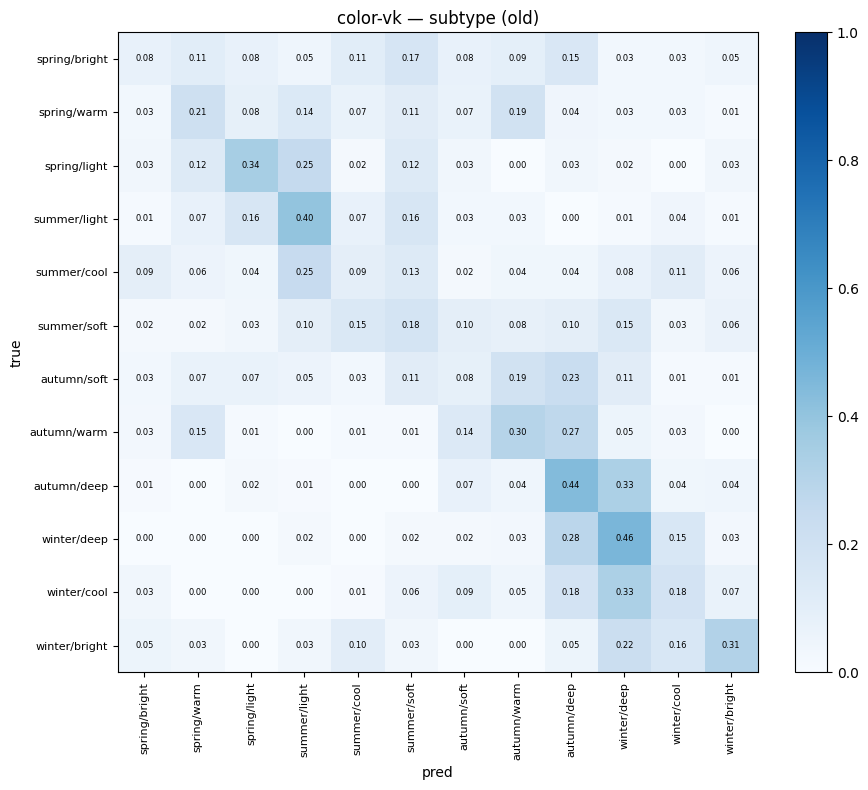

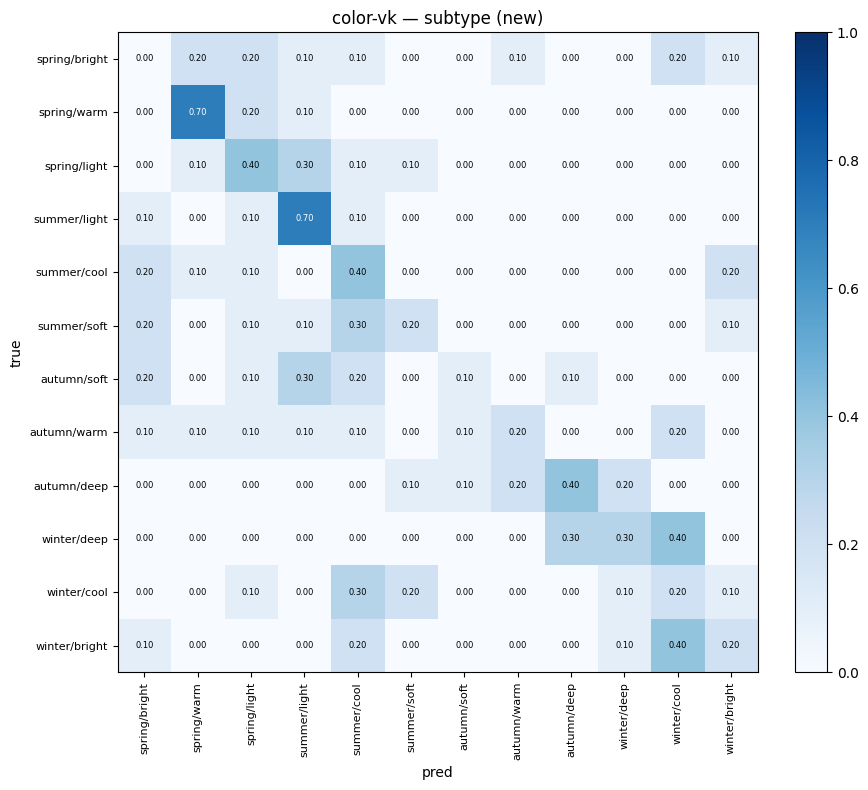

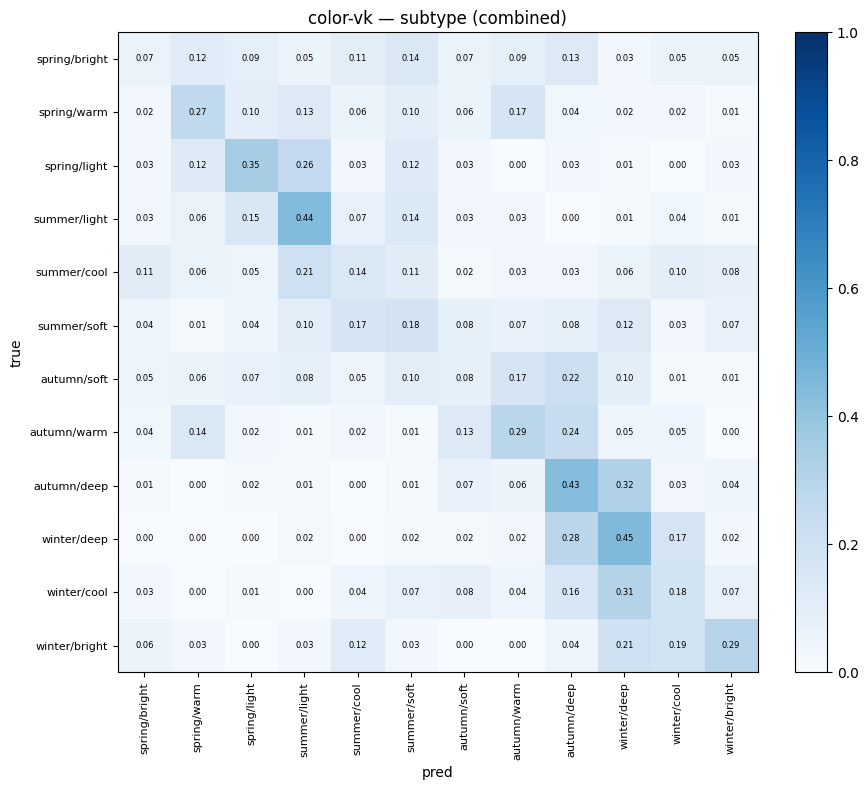

In [62]:
Xtr_vk, vtr_vk = build_color_features(trP_m, "vk")
Xte_vk, vte_vk = build_color_features(teP_m, "vk")
# Sanity: vk detects the same faces as raw, so the masked lists stay fully valid.
assert vtr_vk.all() and vte_vk.all(), (
    "von Kries dropped an image that raw kept — masks diverged unexpectedly")
res_vk = run_color(Xtr_vk, Xte_vk, "vk")
all_results.append(res_vk["df"])
cm_for(res_vk["sub_pred"],  "color-vk")

## Feature diagnostics

Verifying if features carry signal:
```
a: -green <-> +red
b: -blue <-> +yellow
L: lightness 0-100

H: hue
S: saturation
V: value

med - mediana
p25, p75 - percentiles

```


In [48]:
Xtr_r = res_raw["Xtr"]                       # raw features, aligned to ytr
ytr_sea_r = np.array([SUB2SEA[int(c)] for c in ytr])

def _col(feat):
    return Xtr_r[:, FEAT_NAMES.index(feat)]

warm_ids = [SEASONS.index("spring"), SEASONS.index("autumn")]
cool_ids = [SEASONS.index("summer"), SEASONS.index("winter")]
light_ids = [SEASONS.index("spring"), SEASONS.index("summer")]
deep_ids  = [SEASONS.index("autumn"), SEASONS.index("winter")]

def _grp(ids, feat):
    if feat not in FEAT_NAMES:
        return None
    v = _col(feat)
    return v[np.isin(ytr_sea_r, ids)].mean()

print("=== WARM vs COOL (b / hue axis) ===")
for feat in ["cheek_l__b_med", "forehead__b_med", "chin__b_med",
             "iris__b_med", "hair__b_med", "cheek_l__H_med", "iris__H_med"]:
    w, c = _grp(warm_ids, feat), _grp(cool_ids, feat)
    if w is not None:
        print(f"  {feat:18} warm={w:7.2f} cool={c:7.2f} Δ={w-c:+6.2f}")

print("\n=== LIGHT vs DEEP (L / brightness axis) ===")
for feat in ["cheek_l__L_med", "forehead__L_med", "iris__L_med",
             "hair__L_med", "hair__V_med"]:
    lt, dp = _grp(light_ids, feat), _grp(deep_ids, feat)
    if lt is not None:
        print(f"  {feat:18} light={lt:7.2f} deep={dp:7.2f} Δ={lt-dp:+6.2f}")

=== WARM vs COOL (b / hue axis) ===
  cheek_l__b_med     warm= 149.70 cool= 146.40 Δ= +3.30
  forehead__b_med    warm= 147.60 cool= 144.42 Δ= +3.18
  chin__b_med        warm= 149.03 cool= 145.96 Δ= +3.07
  iris__b_med        warm= 135.69 cool= 132.65 Δ= +3.04
  hair__b_med        warm= 139.78 cool= 134.96 Δ= +4.82
  cheek_l__H_med     warm=  11.80 cool=  13.69 Δ= -1.89
  iris__H_med        warm=  34.39 cool=  48.03 Δ=-13.64

=== LIGHT vs DEEP (L / brightness axis) ===
  cheek_l__L_med     light= 170.05 deep= 160.41 Δ= +9.64
  forehead__L_med    light= 189.70 deep= 173.56 Δ=+16.14
  iris__L_med        light=  84.76 deep=  64.51 Δ=+20.25
  hair__L_med        light=  84.68 deep=  52.05 Δ=+32.63
  hair__V_med        light=  99.89 deep=  63.50 Δ=+36.39


In [49]:
# Overlap check: is the iris hue-angle separation real or washed out by variance?
a = _col("iris__a_med") - 128
b = _col("iris__b_med") - 128
iris_angle = np.degrees(np.arctan2(b, a))
w = iris_angle[np.isin(ytr_sea_r, warm_ids)]
c = iris_angle[np.isin(ytr_sea_r, cool_ids)]
print(f"iris hue-angle: warm={w.mean():.1f}±{w.std():.1f}  "
      f"cool={c.mean():.1f}±{c.std():.1f}")
print("(if std ~ Δ, the feature overlaps heavily and is weaker than it looks)")

iris hue-angle: warm=44.6±55.6  cool=26.8±70.3
(if std ~ Δ, the feature overlaps heavily and is weaker than it looks)


## Comparison

In [50]:
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import cross_val_score

# baselines on the shared train split (for context)
ytr_sea_b = np.array([SUB2SEA[int(c)] for c in ytr])
for strat in ["most_frequent", "stratified"]:
    acc = cross_val_score(DummyClassifier(strategy=strat),
                          Xtr_raw, ytr_sea_b, cv=5,
                          scoring="accuracy").mean()
    print(f"dummy season ({strat:13}): {acc:.3f}")

dummy season (most_frequent): 0.260
dummy season (stratified   ): 0.250


In [76]:
summary = pd.concat(all_results, ignore_index=True)

def show_slice(slice_name, title):
    d = summary[summary["slice"] == slice_name].set_index("method")
    print(f"=== {title} — season 4-class ===")
    print(d[["S_acc", "S_prec", "S_rec", "S_f1", "S_top2"]].round(3).to_string())
    print(f"\n=== {title} — subtype 12-class ===")
    print(d[["T_acc", "T_prec", "T_rec", "T_f1", "T_top3", "T_pm1"]].round(3).to_string())
    print()

show_slice("combined", "COMBINED (main comparison)")
show_slice("new", "NEW (generalization to own dataset)")

=== COMBINED (main comparison) — season 4-class ===
                                     S_acc  S_prec  S_rec   S_f1  S_top2
method                                                                  
CLIP [hier]                          0.542   0.540  0.535  0.532   0.824
CLIP [flat]                          0.542   0.540  0.535  0.532   0.824
FaRL16 frozen + boosting [hier]      0.524   0.516  0.517  0.513   0.832
FaRL16 frozen + boosting [flat]      0.524   0.516  0.517  0.513   0.832
FaRL16 frozen + FC (paper) [hier]    0.532   0.530  0.526  0.525   0.818
FaRL16 frozen + FC (paper) [flat]    0.532   0.530  0.526  0.525   0.818
FaRL16 fine-tuned (2 blocks) [hier]  0.540   0.538  0.539  0.527   0.824
FaRL16 fine-tuned (2 blocks) [flat]  0.540   0.538  0.539  0.527   0.824
color-raw [hier]                     0.551   0.547  0.543  0.543   0.818
color-raw [flat]                     0.551   0.547  0.543  0.543   0.818
color-vk [hier]                      0.534   0.528  0.526  0.524   0.817

### Hierarchical vs flat

flat: softmax of 12 seasons
hierarchical: season -> subseason



In [77]:
# base method name without the [mode] tag, to pair hier vs flat
summary["base"] = summary["method"].str.replace(r" \[(hier|flat)\]$", "", regex=True)

def hier_vs_flat(slice_name):
    d = summary[summary["slice"] == slice_name]
    piv = d.pivot_table(index="base", columns="mode",
                        values=["T_acc", "T_f1", "T_pm1"])
    # flatten columns and compute deltas (hier - flat)
    out = pd.DataFrame(index=piv.index)
    for metric in ["T_acc", "T_f1", "T_pm1"]:
        out[f"{metric}_flat"] = piv[(metric, "flat")]
        out[f"{metric}_hier"] = piv[(metric, "hier")]
        out[f"{metric}_Δ"]    = piv[(metric, "hier")] - piv[(metric, "flat")]
    return out.round(3)

for sl in ["old", "new", "combined"]:
    print(f"=== subtype: hier vs flat — {sl} slice ===")
    print(hier_vs_flat(sl).to_string())
    print()

=== subtype: hier vs flat — old slice ===
                              T_acc_flat  T_acc_hier  T_acc_Δ  T_f1_flat  T_f1_hier  T_f1_Δ  T_pm1_flat  T_pm1_hier  T_pm1_Δ
base                                                                                                                        
CLIP                               0.297       0.297    0.000      0.266      0.265  -0.001       0.585       0.592    0.008
FaRL16 fine-tuned (2 blocks)       0.294       0.285   -0.009      0.268      0.259  -0.009       0.580       0.584    0.003
FaRL16 frozen + FC (paper)         0.283       0.271   -0.012      0.255      0.244  -0.011       0.569       0.575    0.006
FaRL16 frozen + boosting           0.278       0.282    0.004      0.251      0.254   0.003       0.563       0.575    0.012
color-raw                          0.293       0.296    0.002      0.267      0.270   0.004       0.579       0.601    0.022
color-vk                           0.299       0.276   -0.023      0.268      0.251

### Deep Armocromia (paper)


In [78]:
paper = pd.DataFrame([
    {"method": "Deep Armocromia FaRL16 (paper)",
     "S_acc": 0.525, "S_f1": 0.516, "S_top2": 0.815,
     "T_acc": 0.318, "T_f1": 0.310, "T_top3": 0.663},
]).set_index("method")

ours_old = summary[(summary["slice"] == "old") & (summary["mode"] == "hier")].copy()
ours_old["method"] = ours_old["method"].str.replace(r" \[hier\]$", "", regex=True)
ours_old = ours_old.set_index("method")[["S_acc","S_f1","S_top2","T_acc","T_f1","T_top3"]]

compare = pd.concat([paper, ours_old.round(3)])
print("=== OURS (old slice) vs PAPER ===")
print(compare.round(3).to_string())

=== OURS (old slice) vs PAPER ===
                                S_acc   S_f1  S_top2  T_acc   T_f1  T_top3
method                                                                    
Deep Armocromia FaRL16 (paper)  0.525  0.516   0.815  0.318  0.310   0.663
CLIP                            0.531  0.517   0.825  0.297  0.265   0.655
FaRL16 frozen + boosting        0.512  0.499   0.832  0.282  0.254   0.640
FaRL16 frozen + FC (paper)      0.515  0.508   0.810  0.268  0.241   0.611
FaRL16 fine-tuned (2 blocks)    0.525  0.511   0.824  0.304  0.272   0.670
color-raw                       0.548  0.537   0.820  0.296  0.270   0.619
color-vk                        0.532  0.519   0.821  0.276  0.251   0.631
color-raw                       0.548  0.537   0.820  0.296  0.270   0.619
color-raw                       0.548  0.537   0.820  0.296  0.270   0.619
color-vk                        0.532  0.519   0.821  0.276  0.251   0.631
color-raw                       0.548  0.537   0.820  0.296  0.270

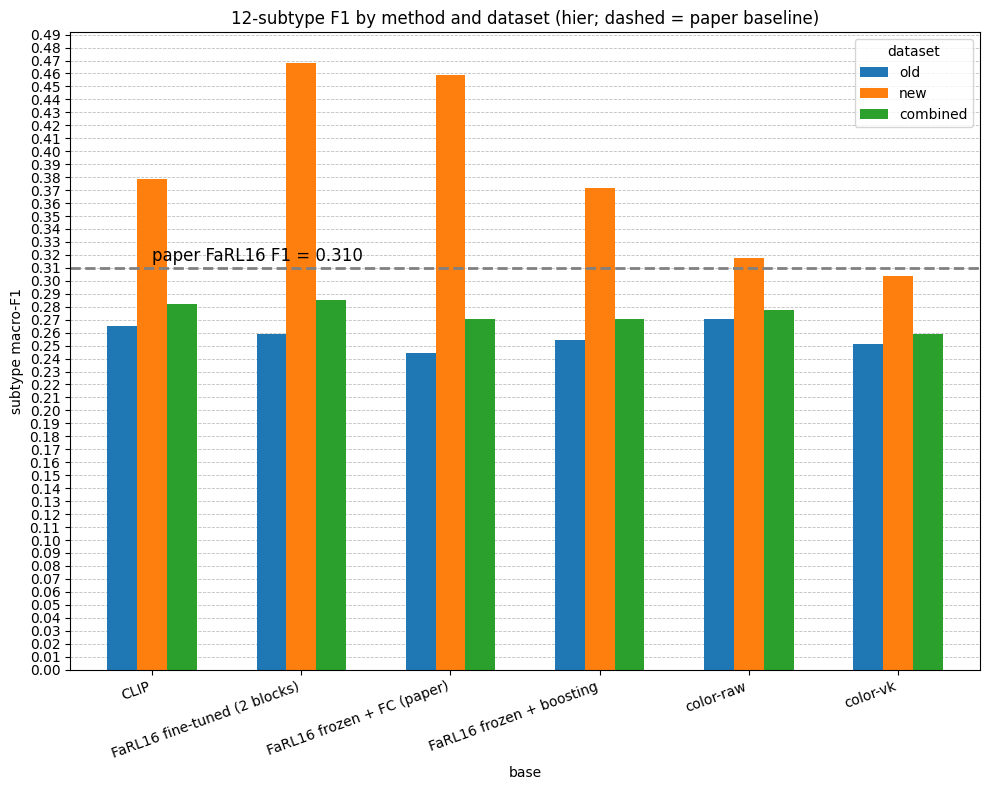

In [105]:
# grouped bar: subtype F1 per method across slices (hierarchical variants only)
from matplotlib.ticker import MultipleLocator

hier_only = summary[summary["mode"] == "hier"].copy()
hier_only["base"] = hier_only["method"].str.replace(r" \[hier\]$", "", regex=True)
piv = hier_only.pivot_table(index="base", columns="slice", values="T_f1")
piv = piv[[c for c in ["old", "new", "combined"] if c in piv.columns]]
ax = piv.plot(kind="bar", figsize=(10, 8), width=0.6)
ax.set_axisbelow(True)
ax.yaxis.set_major_locator(MultipleLocator(0.01))
ax.grid(axis="y", ls="--", lw=0.6, color="grey", alpha=0.5)
ax.axhline(0.310, ls="--", color="grey", lw=2)
ax.text(0, 0.315, "paper FaRL16 F1 = 0.310", fontsize=12, color="black")
ax.set_ylabel("subtype macro-F1")
ax.set_title("12-subtype F1 by method and dataset (hier; dashed = paper baseline)")
ax.legend(title="dataset")
plt.xticks(rotation=20, ha="right")
plt.tight_layout(); plt.show()

### Metrics

confusion matrix

new metric: +-1 season


In [123]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, top_k_accuracy_score)
import pandas as pd

# cyclic +-1 season tolerance: spring(0)-summer(1)-autumn(2)-winter(3)-spring...
def _season_adjacent(true_sea, pred_sea, tol=1):
    d = abs(true_sea - pred_sea)
    d = min(d, 4 - d)          # wrap-around on the 4-season cycle
    return d <= tol

def _season_tol_acc(pred, y):
    """Fraction where the predicted subtype's season is within +-1 season
    (cyclic) of the true subtype's season."""
    return float(np.mean([
        _season_adjacent(SUB2SEA[int(yt)], SUB2SEA[int(yp)])
        for yt, yp in zip(y, pred)
    ]))

def metrics_table(clf_sea, clf_sub, X, y, src, method, which="old"):
    """Paper-format metrics for the 3 modes plus a season +-1 tolerance column:
    4-season, 12-subtype flat, 12-subtype hierarchical (4->3)."""
    m = (src == which) if which in ("old", "new") else np.ones(len(y), bool)
    if m.sum() == 0:
        print("no samples for", which); return
    Xs, ys = X[m], y[m]
    ys_sea = np.array([SUB2SEA[int(c)] for c in ys])

    sea_pred, sub_hier, sub_proba = predict_hierarchical(clf_sea, clf_sub, Xs)
    _,        sub_flat, _          = predict_flat(clf_sea, clf_sub, Xs)
    sea_proba = clf_sea.predict_proba(Xs)

    def _topk(yt, proba, classes, k):
        try:    return top_k_accuracy_score(yt, proba, k=k, labels=classes)
        except Exception: return float("nan")

    def _row(name, yt, yp, nclass, proba, k, classes, sea_tol_pred=None):
        r = {
            "task": name,
            "acc":  accuracy_score(yt, yp),
            "prec": precision_score(yt, yp, average="macro",
                                    labels=list(range(nclass)), zero_division=0),
            "rec":  recall_score(yt, yp, average="macro",
                                 labels=list(range(nclass)), zero_division=0),
            "f1":   f1_score(yt, yp, average="macro",
                             labels=list(range(nclass)), zero_division=0),
            "top_k": _topk(yt, proba, classes, k),
            # season +-1 tolerance: only meaningful for subtype tasks
            "season_pm1": (_season_tol_acc(sea_tol_pred, ys)
                           if sea_tol_pred is not None else float("nan")),
        }
        return r

    rows = [
        _row("4-season",        ys_sea, sea_pred, 4,  sea_proba, 2, clf_sea.classes_),
        _row("12-subtype flat", ys,     sub_flat, 12, sub_proba, 3, clf_sub.classes_,
             sea_tol_pred=sub_flat),
        _row("12-subtype hier", ys,     sub_hier, 12, sub_proba, 3, clf_sub.classes_,
             sea_tol_pred=sub_hier),
    ]
    df = pd.DataFrame(rows).set_index("task").round(3)
    print(f"\n=== {method}  ({which} slice, n={int(m.sum())}) ===")
    print(df.to_string())
    return df

In [137]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

def _cm(ax, y_true, y_pred, labels, names, title):
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    cmn = cm / np.clip(cm.sum(1, keepdims=True), 1, None)
    im = ax.imshow(cmn, cmap="Blues", vmin=0, vmax=1)
    n = len(labels)
    ax.set_xticks(range(n)); ax.set_xticklabels(names, rotation=90, fontsize=8)
    ax.set_yticks(range(n)); ax.set_yticklabels(names, fontsize=8)
    for i in range(n):
        for j in range(n):
            ax.text(j, i, f"{cmn[i,j]:.2f}", ha="center", va="center",
                    fontsize=12, color="white" if cmn[i,j] > 0.5 else "black")
    ax.set_title(title); ax.set_xlabel("pred"); ax.set_ylabel("true")

def all_confusions(clf_sea, clf_sub, X, y, src, method, which="old"):
    """Three confusion matrices for one method on one slice:
    (1) 4-season, (2) 12-subtype FLAT, (3) 12-subtype HIERARCHICAL (4->3)."""
    m = (src == which) if which in ("old", "new") else np.ones(len(y), bool)
    if m.sum() == 0:
        print("no samples for", which); return
    Xs, ys = X[m], y[m]
    ys_sea = np.array([SUB2SEA[int(c)] for c in ys])

    sea_pred, sub_hier, _ = predict_hierarchical(clf_sea, clf_sub, Xs)
    _,        sub_flat, _ = predict_flat(clf_sea, clf_sub, Xs)

    fig, axes = plt.subplots(1, 3, figsize=(26, 8))
    _cm(axes[0], ys_sea, sea_pred, list(range(4)),
        [s.capitalize() for s in SEASONS], f"{method} — 4 seasons ({which})")
    _cm(axes[1], ys, sub_flat, RING, RING_NAMES,
        f"{method} — 12 subtypes flat ({which})")
    _cm(axes[2], ys, sub_hier, RING, RING_NAMES,
        f"{method} — 12 subtypes hier 4->3 ({which})")
    plt.tight_layout(); plt.show()

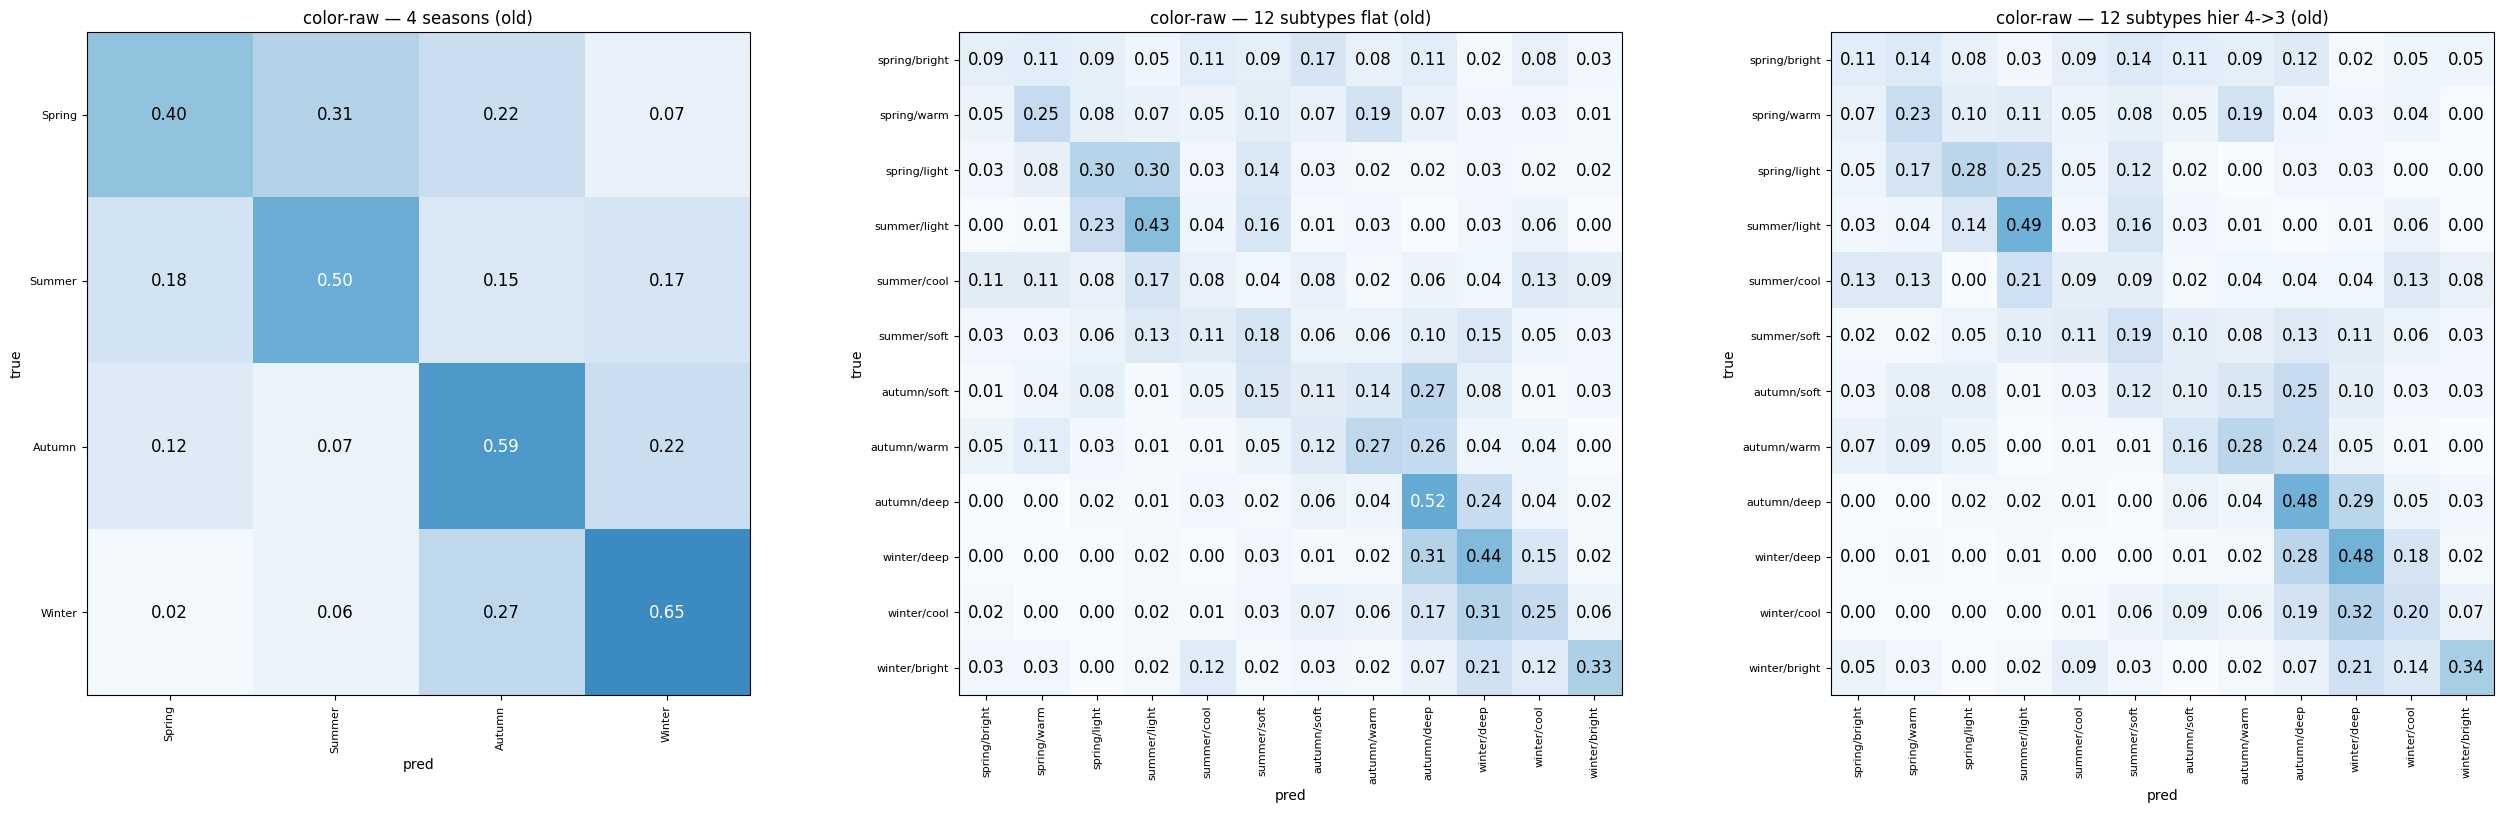

In [138]:
# color-raw:
all_confusions(res_raw["clf_sea"], res_raw["clf_sub"], Xte_raw, yte, src_te,
               "color-raw", which="old")


In [139]:
metrics_table(res_raw["clf_sea"], res_raw["clf_sub"], Xte_raw, yte, src_te,
              "color-raw", which="old")


=== color-raw  (old slice, n=910) ===
                   acc   prec    rec     f1  top_k  season_pm1
task                                                          
4-season         0.548  0.543  0.537  0.537  0.820         NaN
12-subtype flat  0.293  0.276  0.270  0.267  0.619       0.855
12-subtype hier  0.296  0.277  0.274  0.270  0.619       0.865


,acc,prec,rec,f1,top_k,season_pm1
task,,,,,,
4-season,0.548,0.543,0.537,0.537,0.820,NaN
12-subtype flat,0.293,0.276,0.270,0.267,0.619,0.855
12-subtype hier,0.296,0.277,0.274,0.270,0.619,0.865


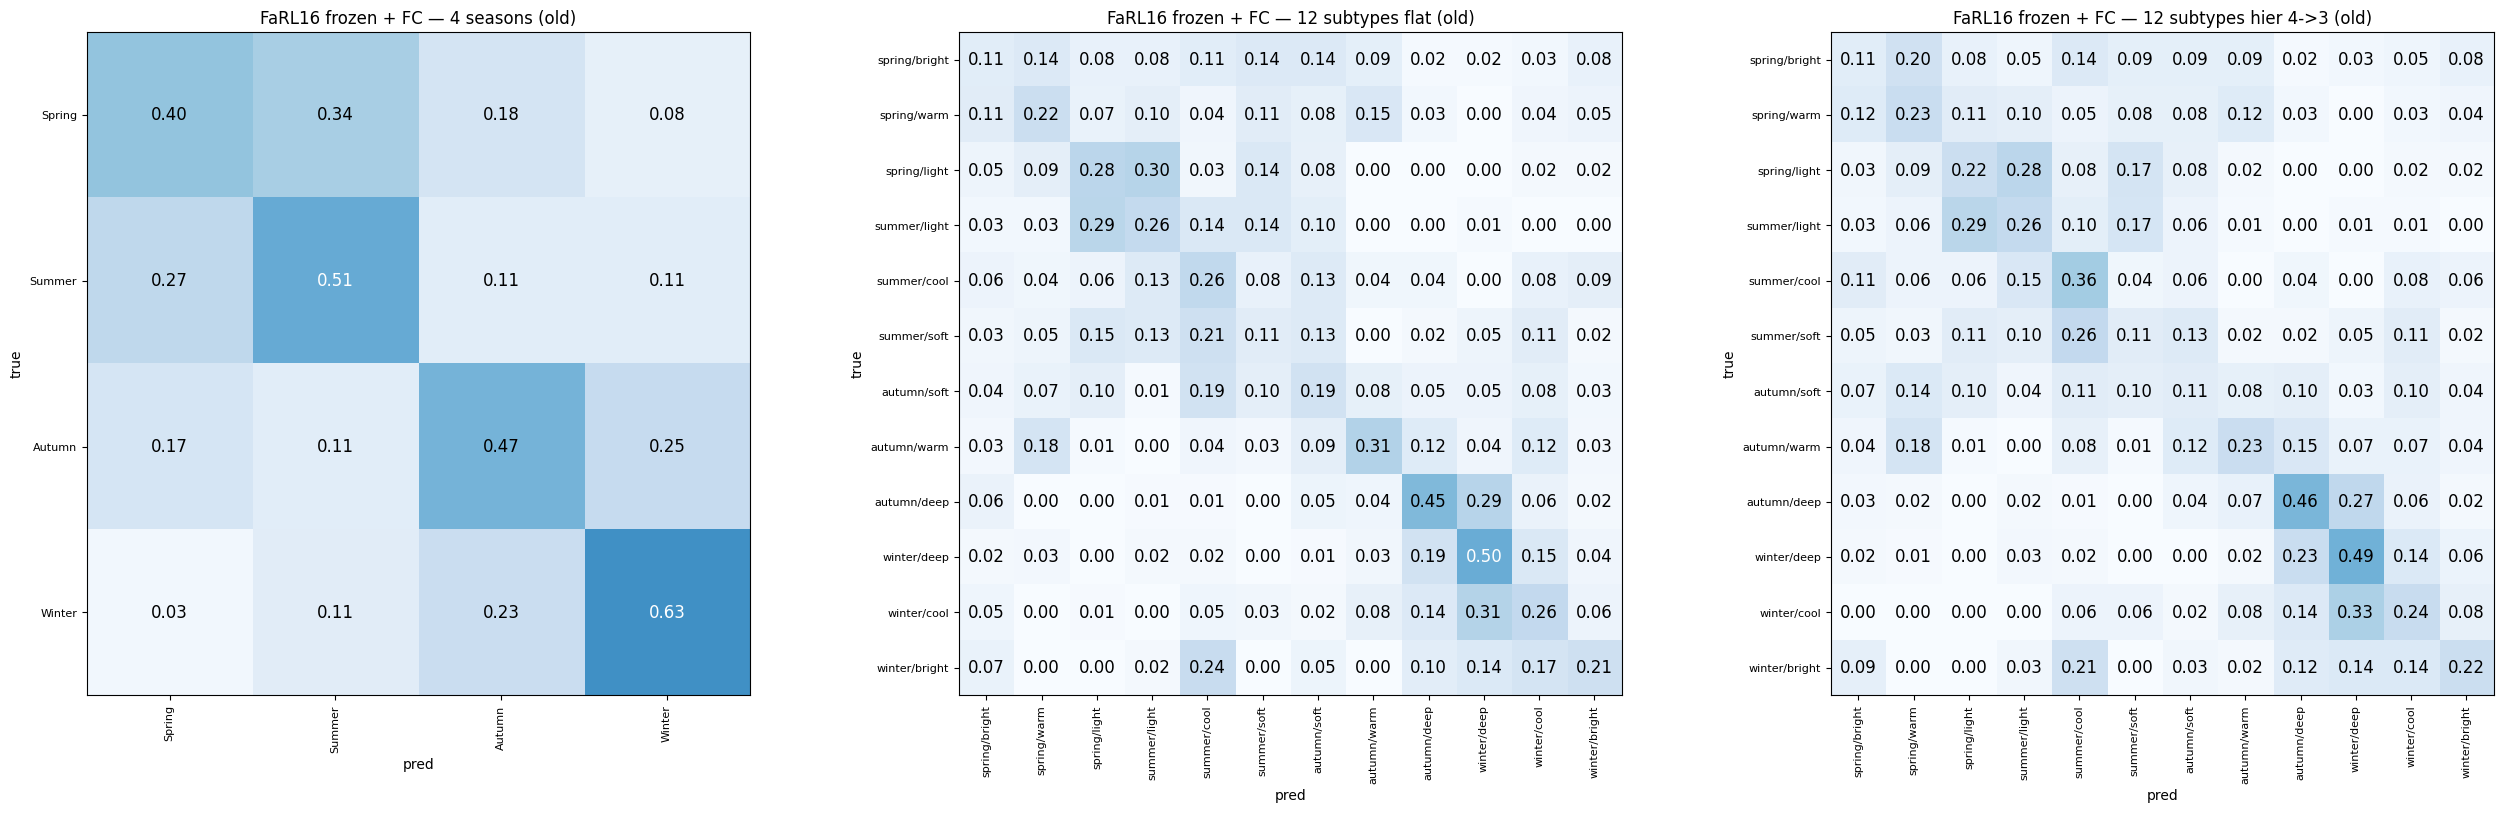

In [140]:
# FaRL16 frozen + FC:
all_confusions(fc_sea, fc_sub, Fte, yte, src_te, "FaRL16 frozen + FC", which="old")

In [141]:
metrics_table(fc_sea,   fc_sub,   Fte, yte, src_te, "FaRL16 frozen + FC", which="old")


=== FaRL16 frozen + FC  (old slice, n=910) ===
                   acc   prec    rec     f1  top_k  season_pm1
task                                                          
4-season         0.511  0.502  0.505  0.502  0.810         NaN
12-subtype flat  0.287  0.265  0.264  0.262  0.642       0.863
12-subtype hier  0.275  0.248  0.253  0.248  0.642       0.858


,acc,prec,rec,f1,top_k,season_pm1
task,,,,,,
4-season,0.511,0.502,0.505,0.502,0.810,NaN
12-subtype flat,0.287,0.265,0.264,0.262,0.642,0.863
12-subtype hier,0.275,0.248,0.253,0.248,0.642,0.858


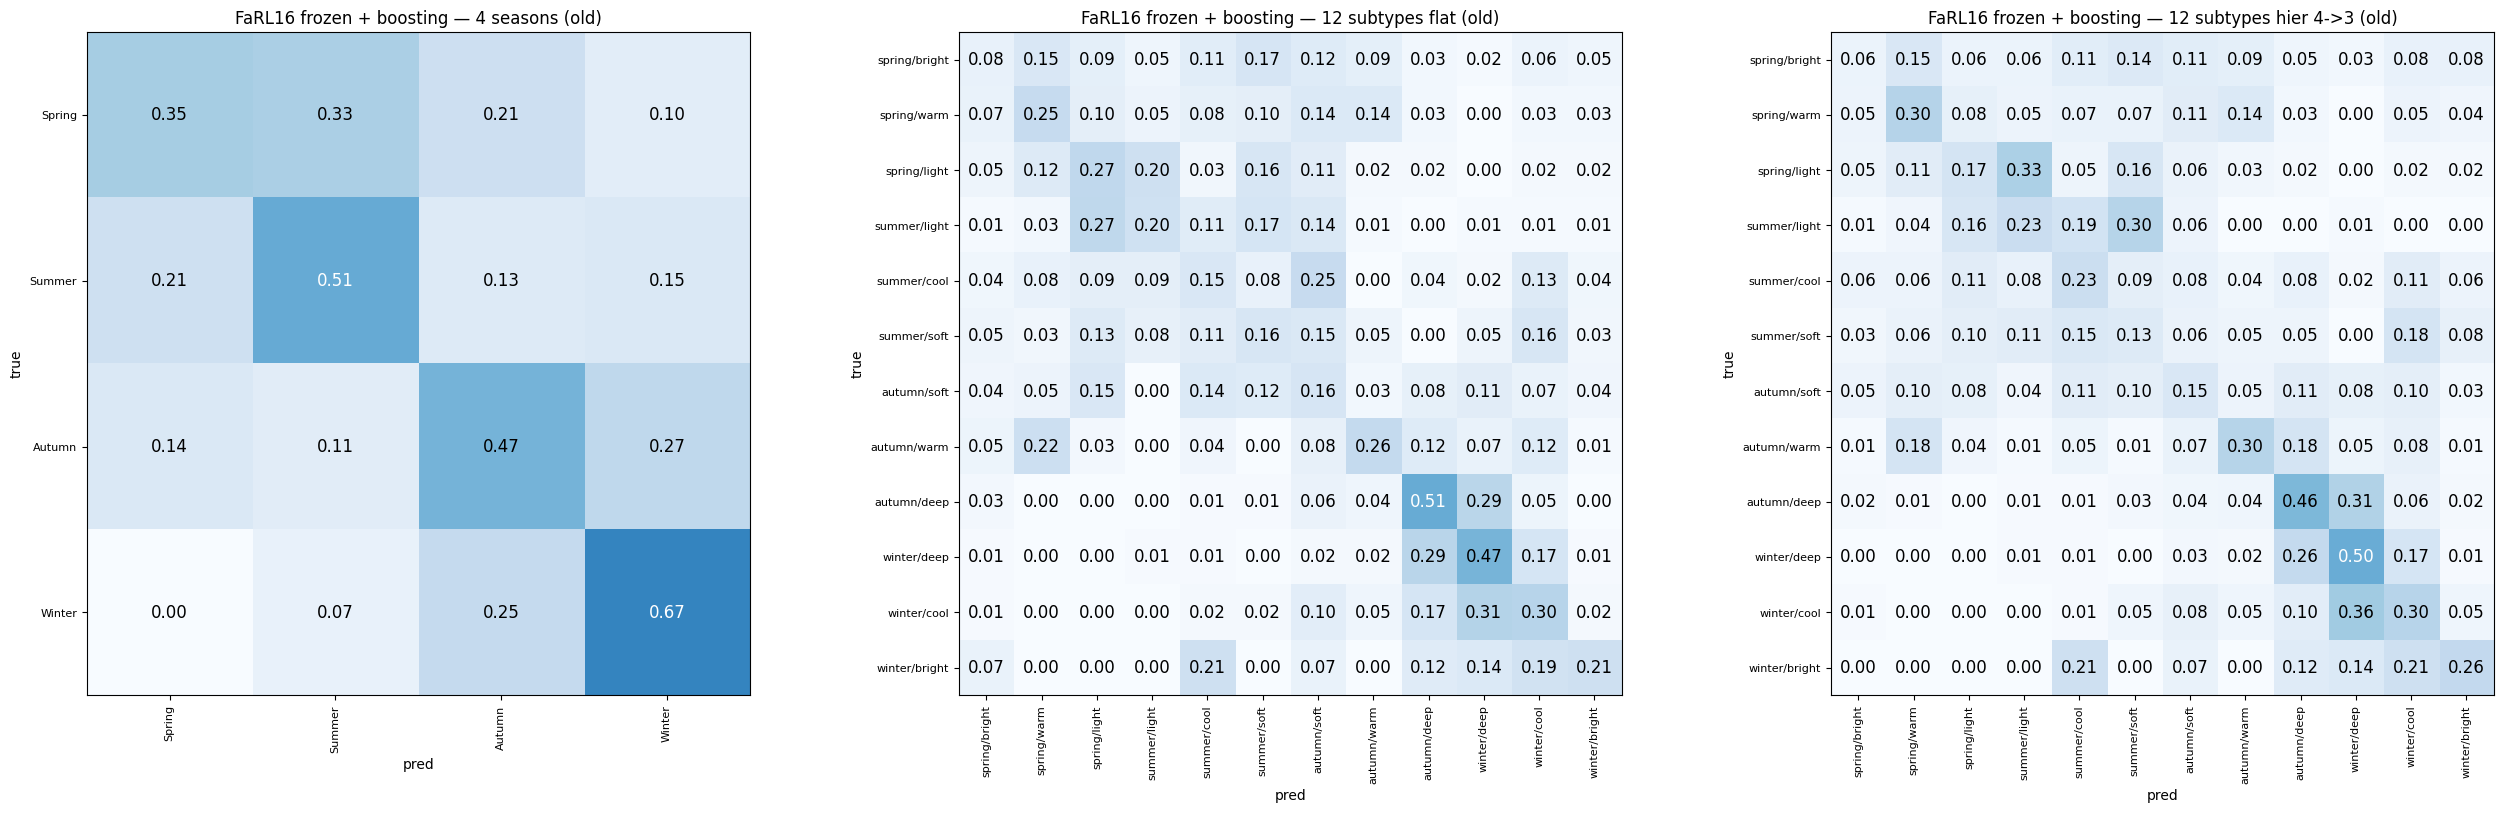

In [142]:
# FaRL16 frozen + boosting:
all_confusions(farl_sea, farl_sub, Fte, yte, src_te, "FaRL16 frozen + boosting", which="old")

In [143]:
metrics_table(farl_sea, farl_sub, Fte, yte, src_te, "FaRL16 frozen + boosting", which="old")



=== FaRL16 frozen + boosting  (old slice, n=910) ===
                   acc   prec    rec     f1  top_k  season_pm1
task                                                          
4-season         0.512  0.503  0.503  0.499  0.832         NaN
12-subtype flat  0.278  0.265  0.250  0.251  0.640       0.851
12-subtype hier  0.282  0.261  0.257  0.254  0.640       0.862


,acc,prec,rec,f1,top_k,season_pm1
task,,,,,,
4-season,0.512,0.503,0.503,0.499,0.832,NaN
12-subtype flat,0.278,0.265,0.250,0.251,0.640,0.851
12-subtype hier,0.282,0.261,0.257,0.254,0.640,0.862


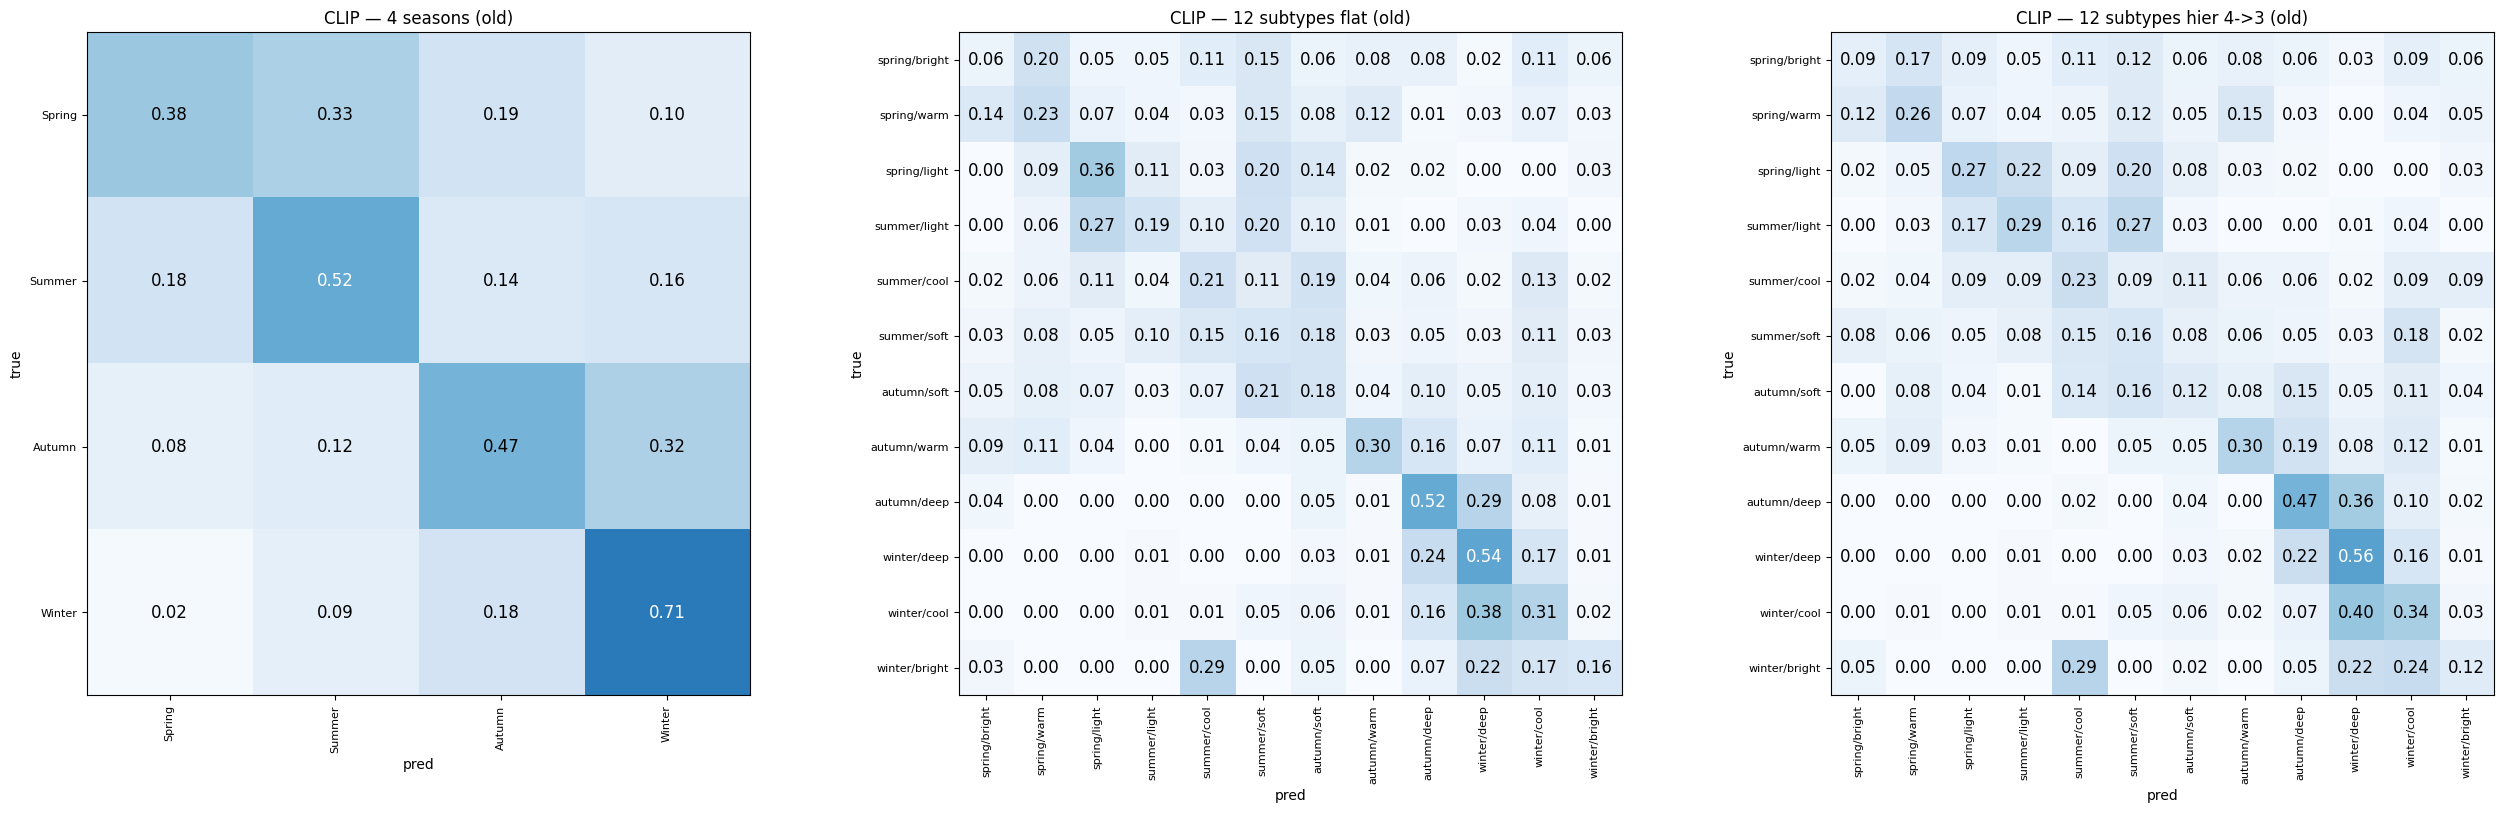

In [144]:
# CLIP:
all_confusions(clip_sea, clip_sub, Ete, yte, src_te, "CLIP", which="old")

In [145]:
metrics_table(clip_sea, clip_sub, Ete, yte, src_te, "CLIP", which="old")


=== CLIP  (old slice, n=910) ===
                   acc   prec    rec     f1  top_k  season_pm1
task                                                          
4-season         0.531  0.528  0.521  0.517  0.825         NaN
12-subtype flat  0.297  0.283  0.267  0.266  0.655       0.860
12-subtype hier  0.297  0.279  0.267  0.265  0.655       0.876


,acc,prec,rec,f1,top_k,season_pm1
task,,,,,,
4-season,0.531,0.528,0.521,0.517,0.825,NaN
12-subtype flat,0.297,0.283,0.267,0.266,0.655,0.860
12-subtype hier,0.297,0.279,0.267,0.265,0.655,0.876
